[Device] CPU  (switch to T4 GPU in Colab for full speed)
  PINN v10 — 1-D One-Way Hydromechanical  (two-stage pipeline)
  Stage 1 : Physics discovery   — 80/10/10 temporal split
  Stage 2 : State assimilation  — rolling windows, frozen VG

──────────────────────────────────────────────────────────────
[CSV] /content/105_pinn.csv
──────────────────────────────────────────────────────────────
  Rows:20777  Cols:['unnamed: 0', 'timestamp', 'devid', 'soil_', 'rain', 'temp', 'humi', 'geo', 'soil']  sep=','
  T_MAX → 348h
  Time : '%Y-%m-%d %H:%M:%S'  [0.0,346.3]h
  Depth: SENSOR_DEPTH_M=0.3m from surface → z=2.70m (Sandy CL)
  Soil : θ=[0.336,0.500]  mean=0.413
  Built: rain=20777  θ_obs=20777

  ┌─────────────────────────────────────────────────────┐
  │ PINN v10 — 1-D One-Way Hydromechanical             │
  │ Rows    : 20777                                      │
  │ Time    : 0.0–346.3h                                    │
  │ Sensor  : z=2.7m (Sandy CL)                               │
 

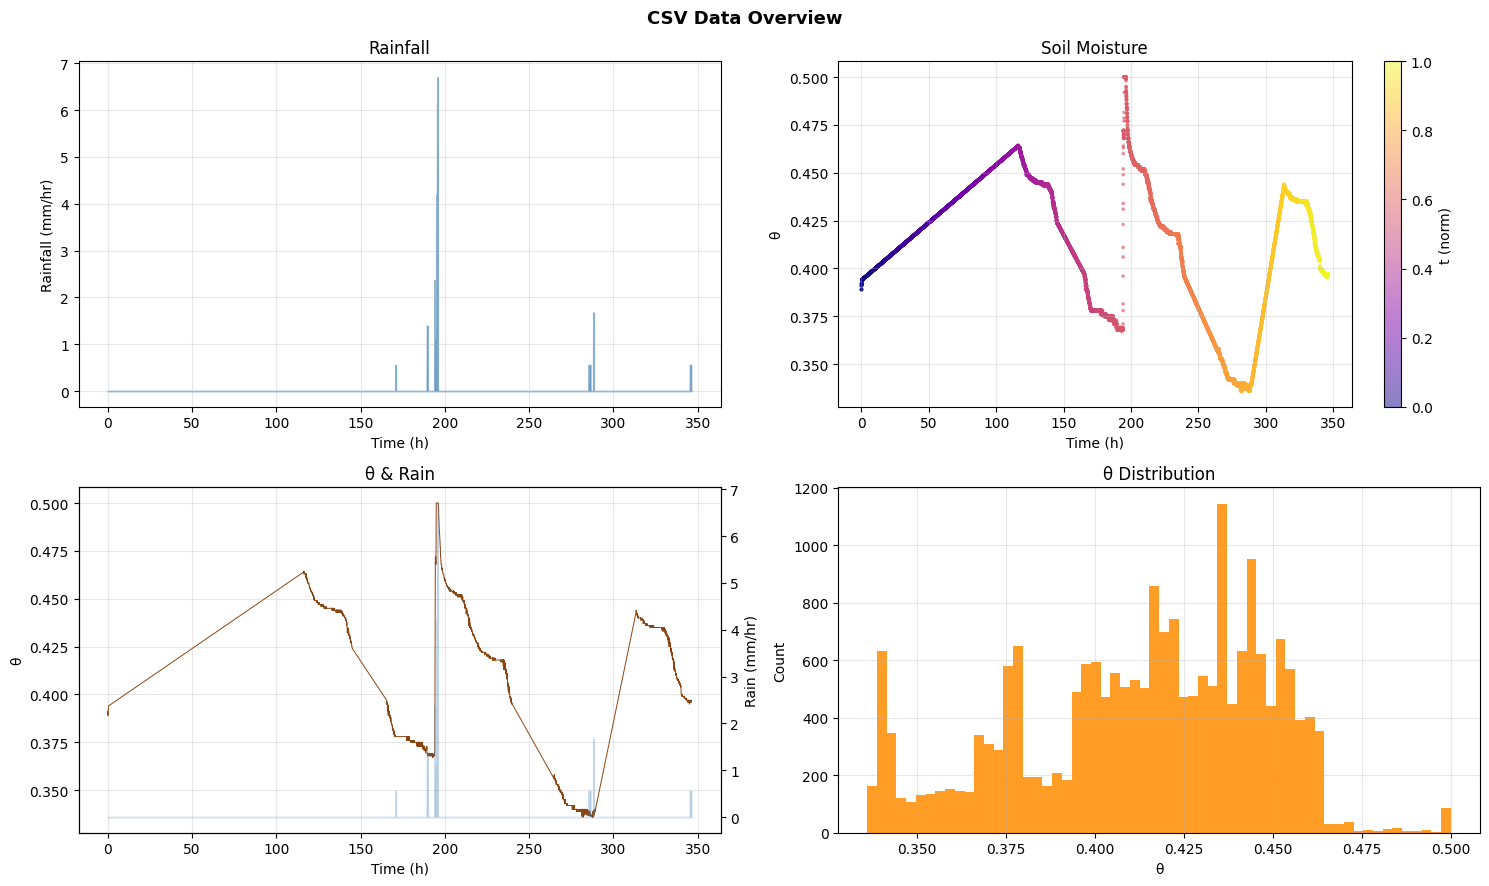


  ══ DATA DIAGNOSIS (chronological 80/10/10) ══════════════════
  Train  θ: mean=0.4168  std=0.0323  range=[0.3400,0.5000]  t=[0–277h]  n=16621
  Val    θ: mean=0.3702  std=0.0321  range=[0.3360,0.4352]  t=[277–312h]  n=2078
  Test   θ: mean=0.4249  std=0.0159  range=[0.3950,0.4440]  t=[312–346h]  n=2078

  Val  drift from Train mean : 0.0466 m³/m³  ⚠ expected — future unseen period
  Test drift from Train mean : 0.0081 m³/m³  ✓ OK
  Val θ range adequate       : ✓

  ✓  Drift within acceptable range for temporal split.

  ✓  Chronological split — no temporal leakage.
     Train → Val → Test move strictly forward in time.

  [Plot] Data diagnosis → data_diagnosis.png


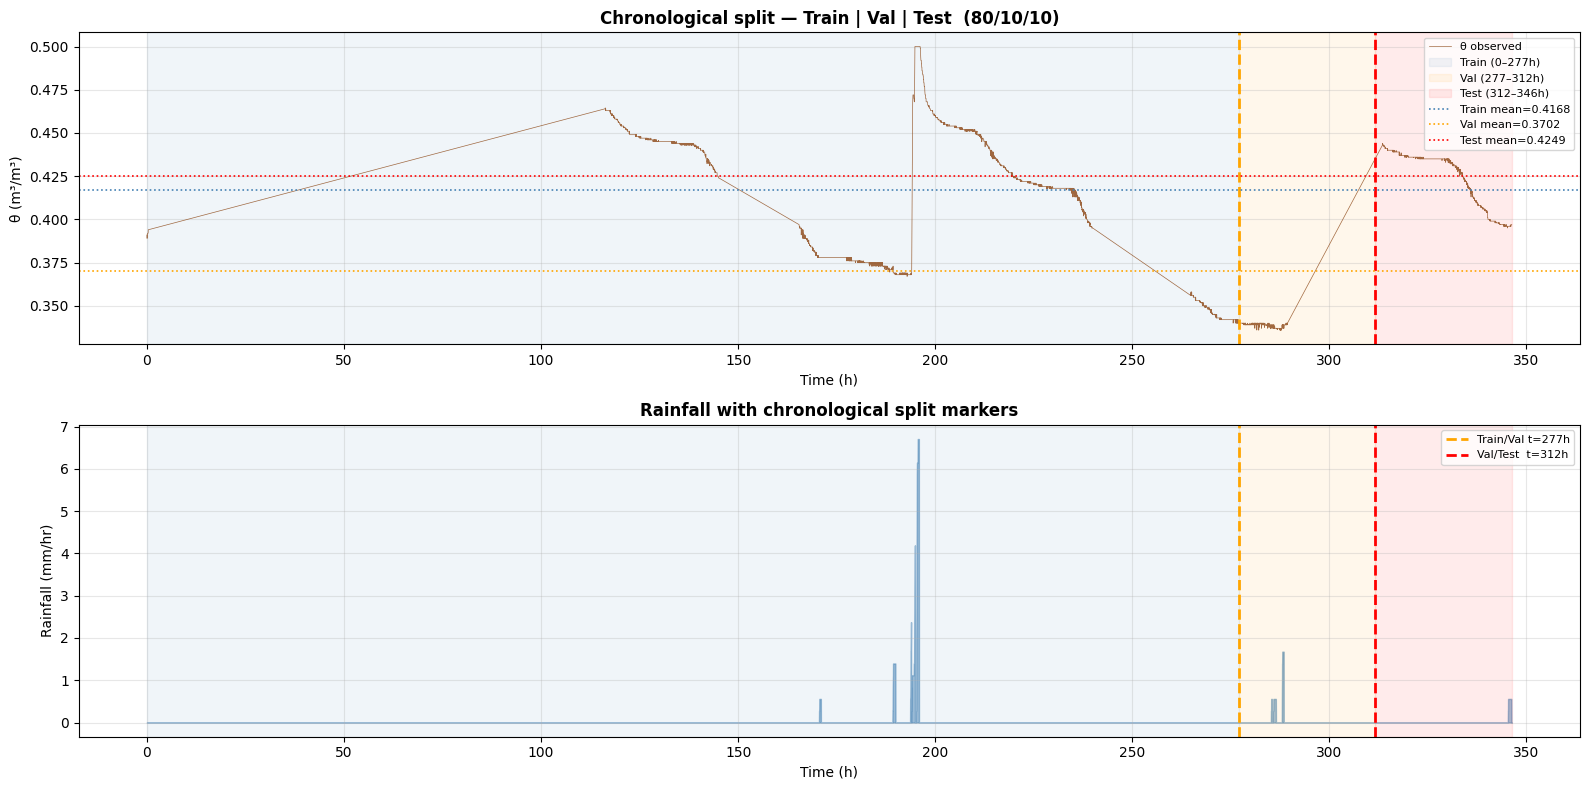

  [Sampler] Rain importance CDF over 20777 pts

  STAGE 1 — Physics Discovery
  Learns VG parameters from 80% train window.
  Held-out 10% test validates generalisation.

════════════════════════════════════════════════════════════════════════
  PINN v10 — ENSEMBLE  2 seeds
  v10 fixes: [v10-F1] Richards gravity sign  [v10-F2] BC_top flux
  Exclusion criterion: seed_failed OR val RMSE > 0.06
════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────
  Seed 0  (1/2)
────────────────────────────────────────────────────────────────────────

[PINN v10 — 1-D One-Way Hydromechanical | v10 Fixes Applied]
  Inputs  : (z_norm, t_norm)
  Outputs : psi (network head);  theta via VG(psi)  [v10-F4]
  Chain   : Richards → u_w → σ′_n → FoS  (one-way)
  v10 Fix : [v10-F1] gravity sign  [v10-F2] BC_top flux  [v10-F3] psi scale/shift
            [v10-F4] theta coupled to psi via VG retention curve (head_theta removed

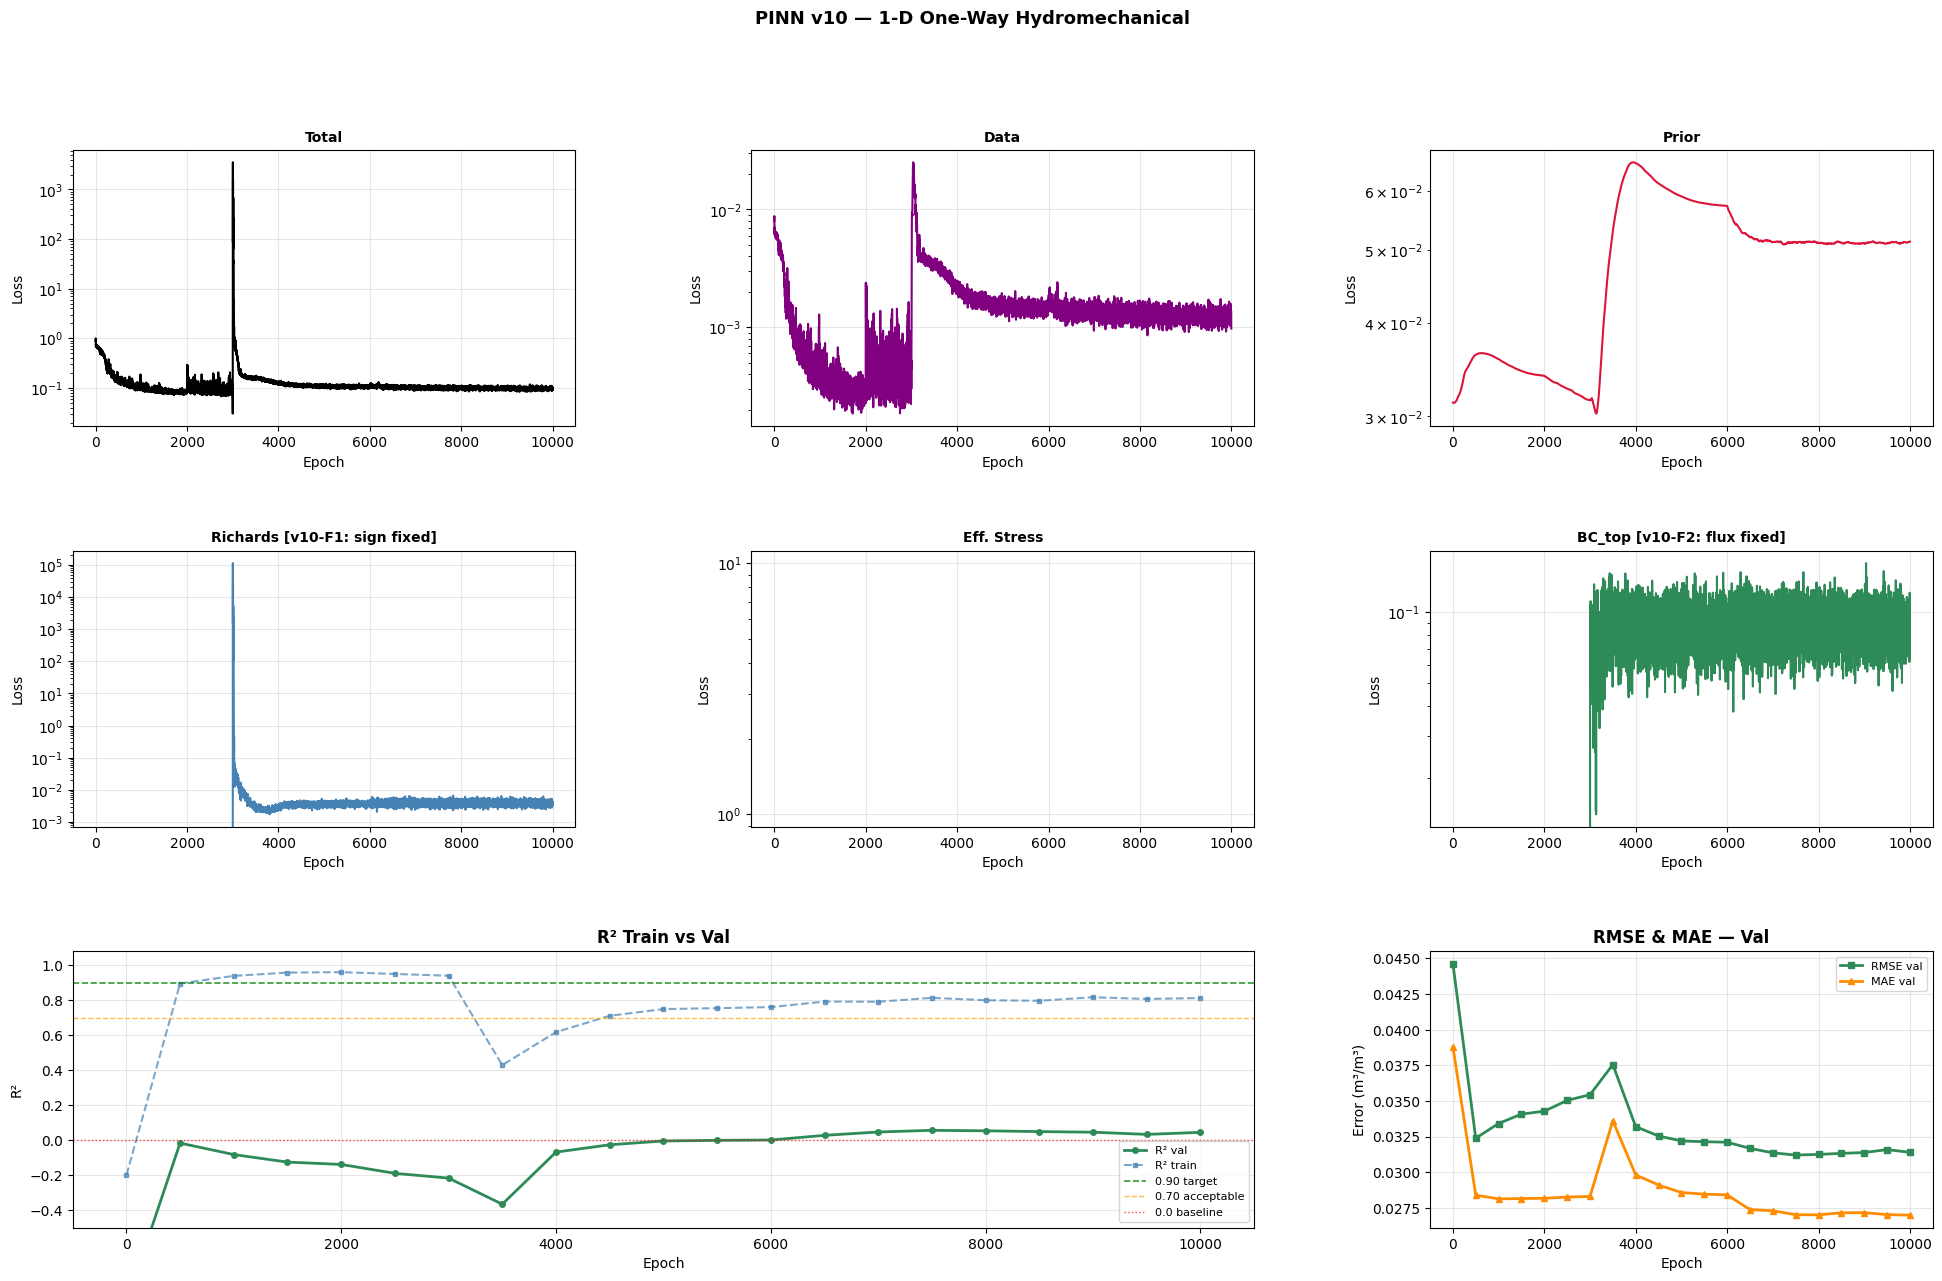

[Plot] Inverse params → inverse_params_1d.png


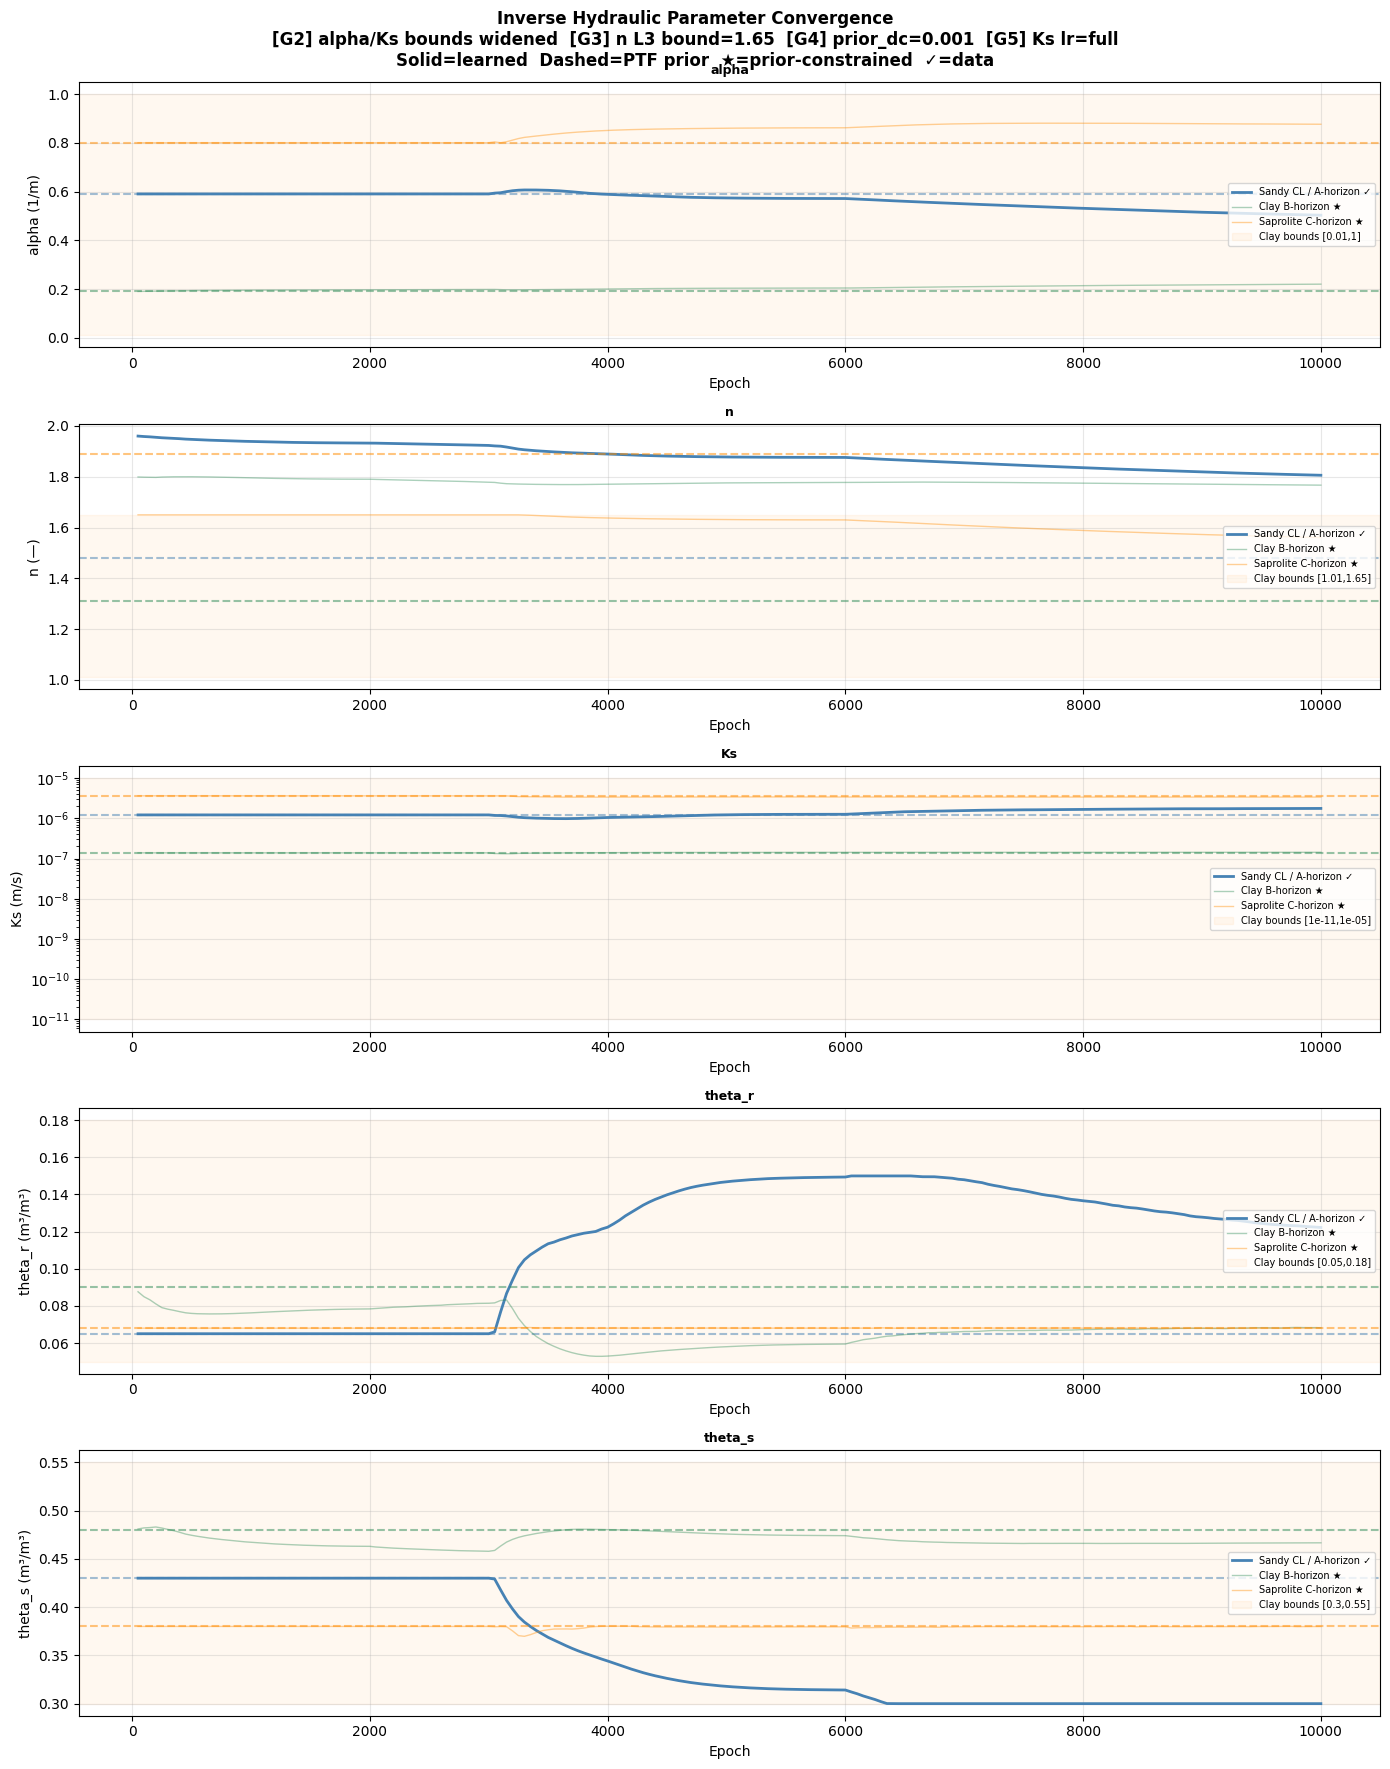

[Plot] Ensemble → ensemble_1d.png


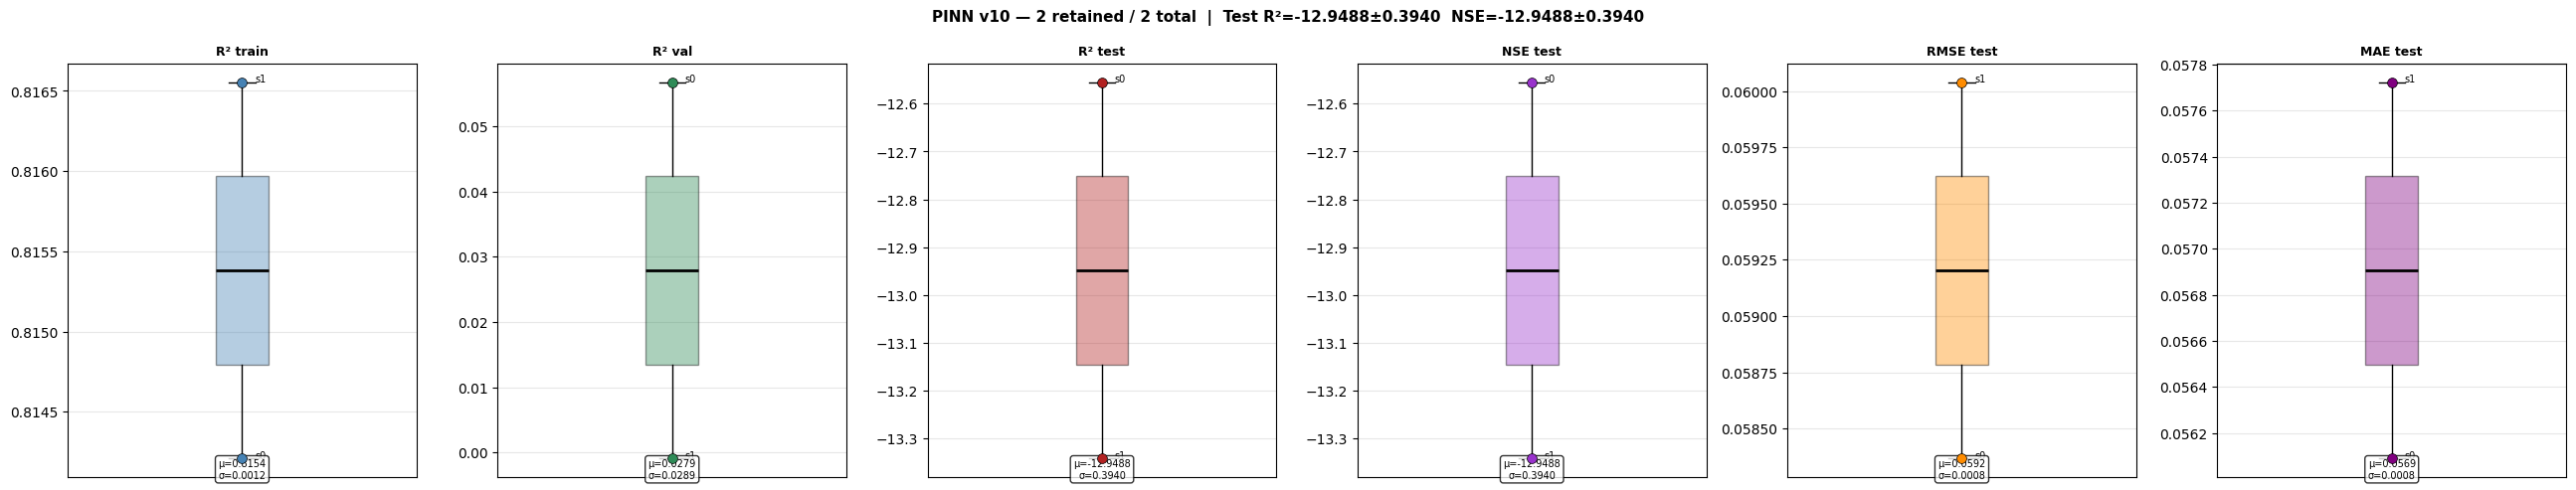

[Plot] Parity [train] → parity_train_1d.png


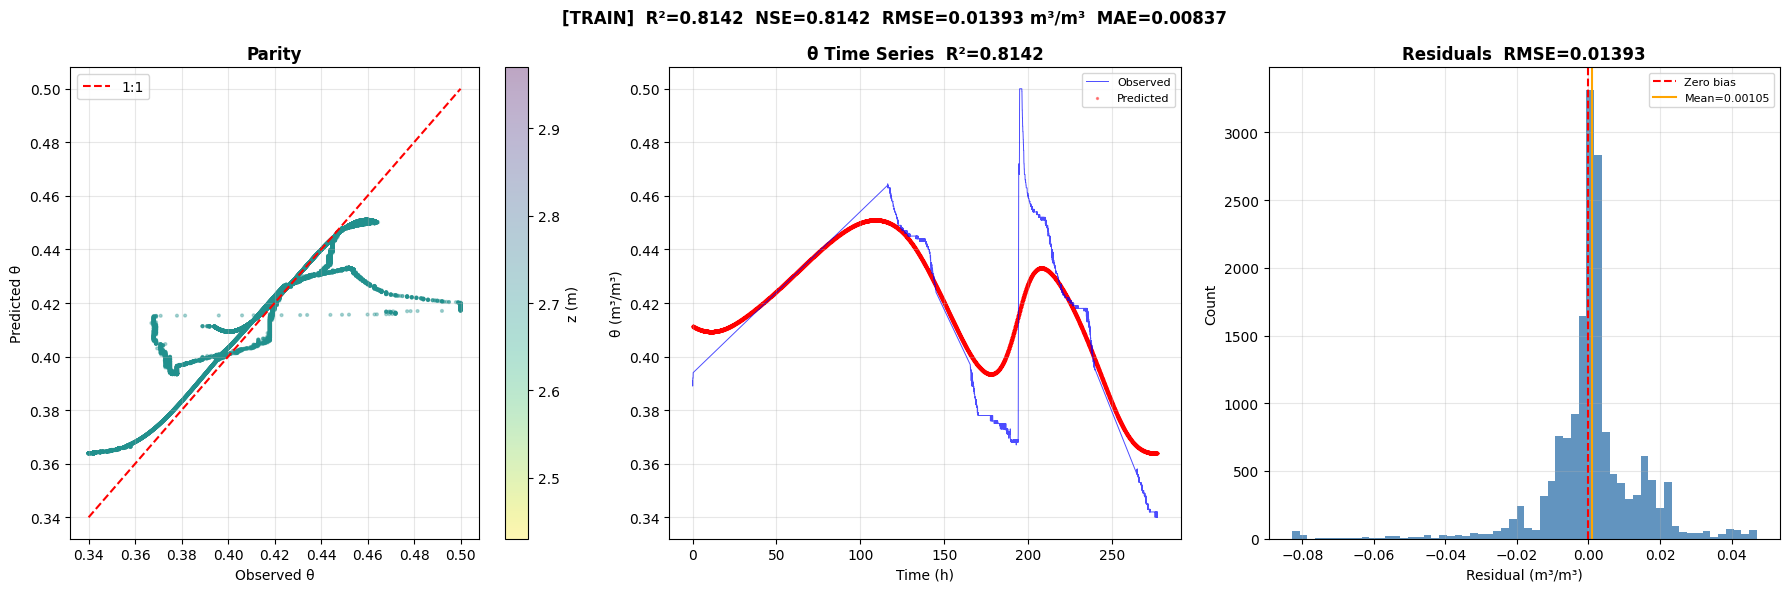

[Plot] Parity [val] → parity_val_1d.png


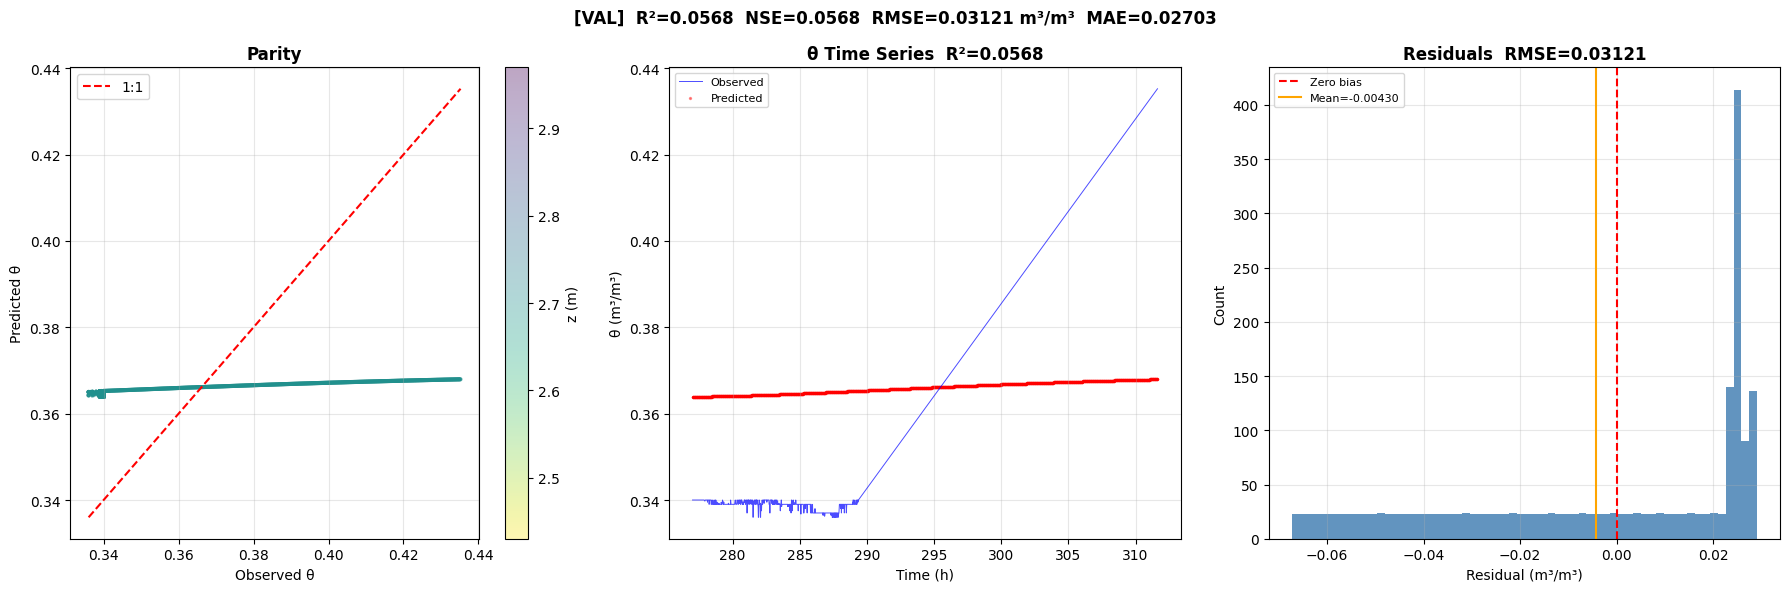

[Plot] Parity [test] → parity_test_1d.png


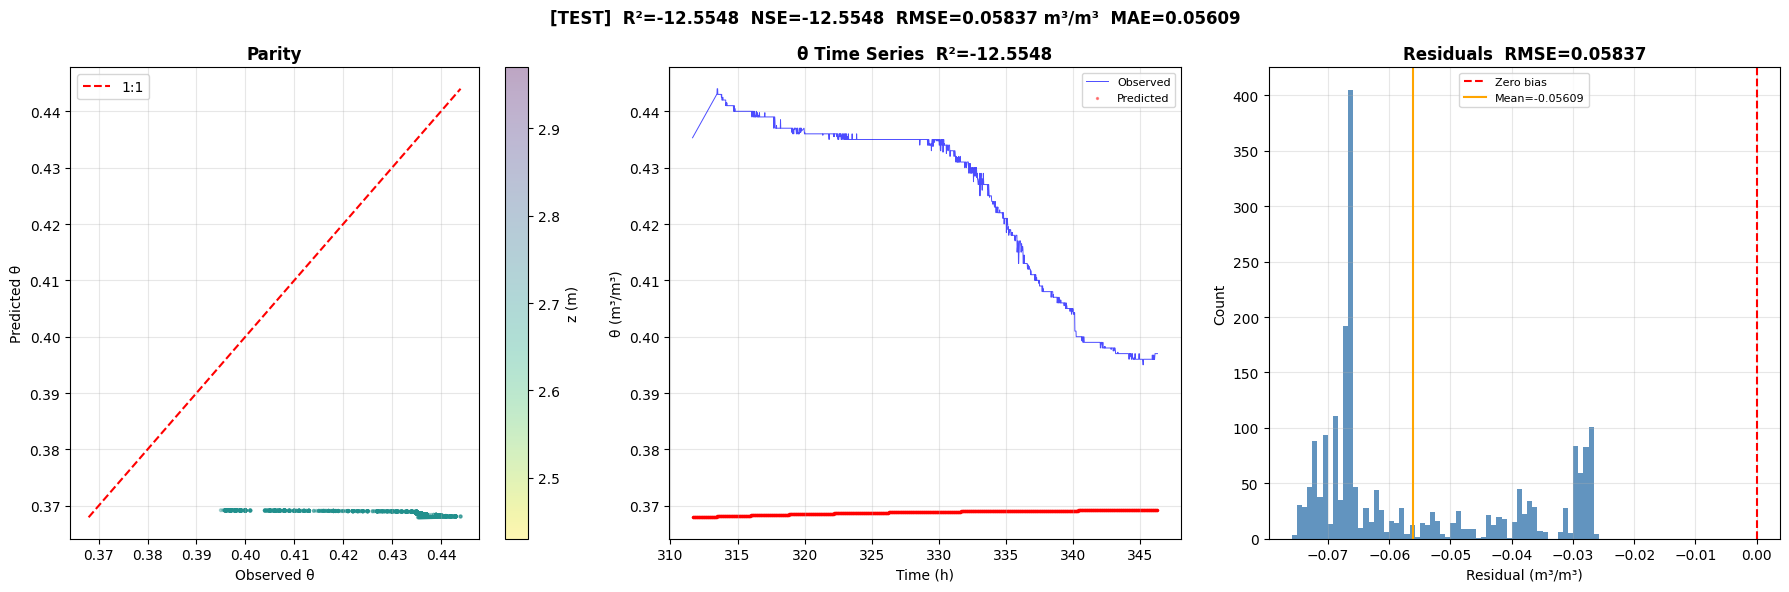

[Plot] Coupling chain → coupling_chain_1d.png


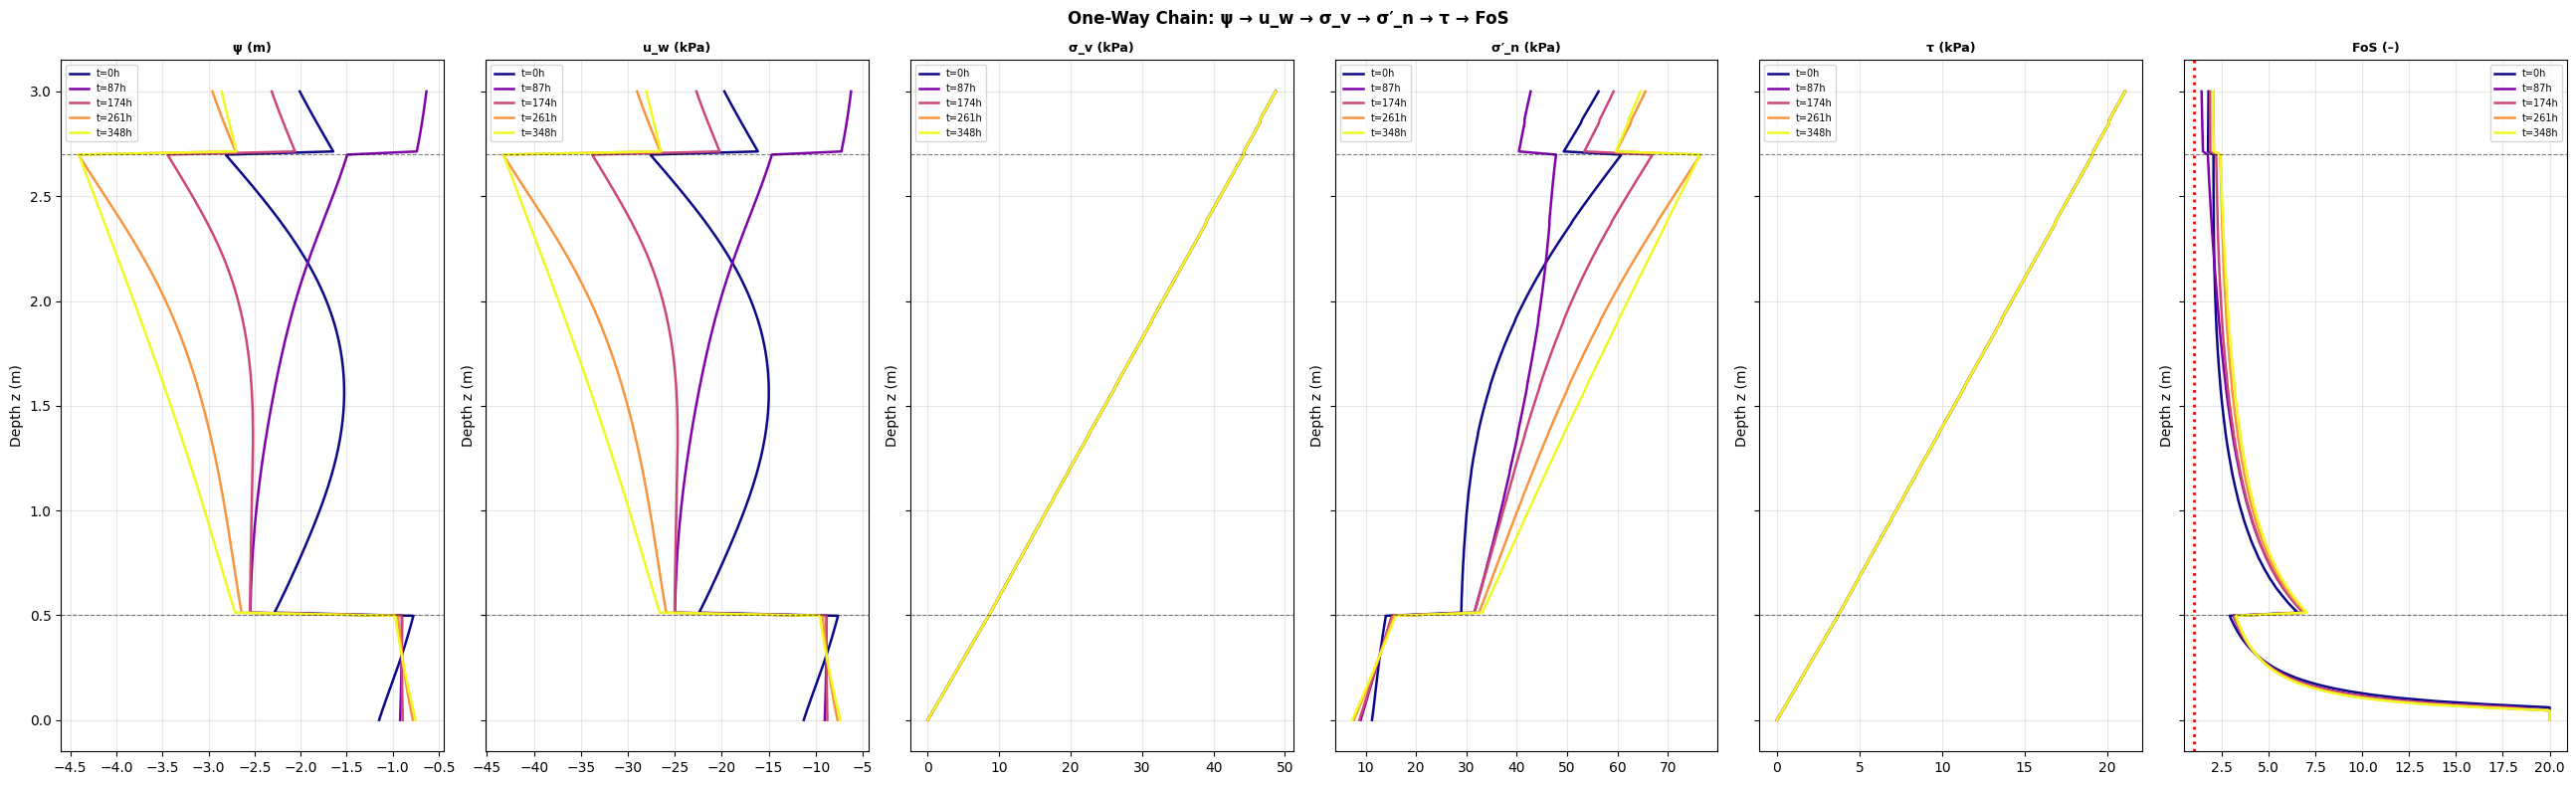

[Plot] Heatmap → heatmap_1d.png


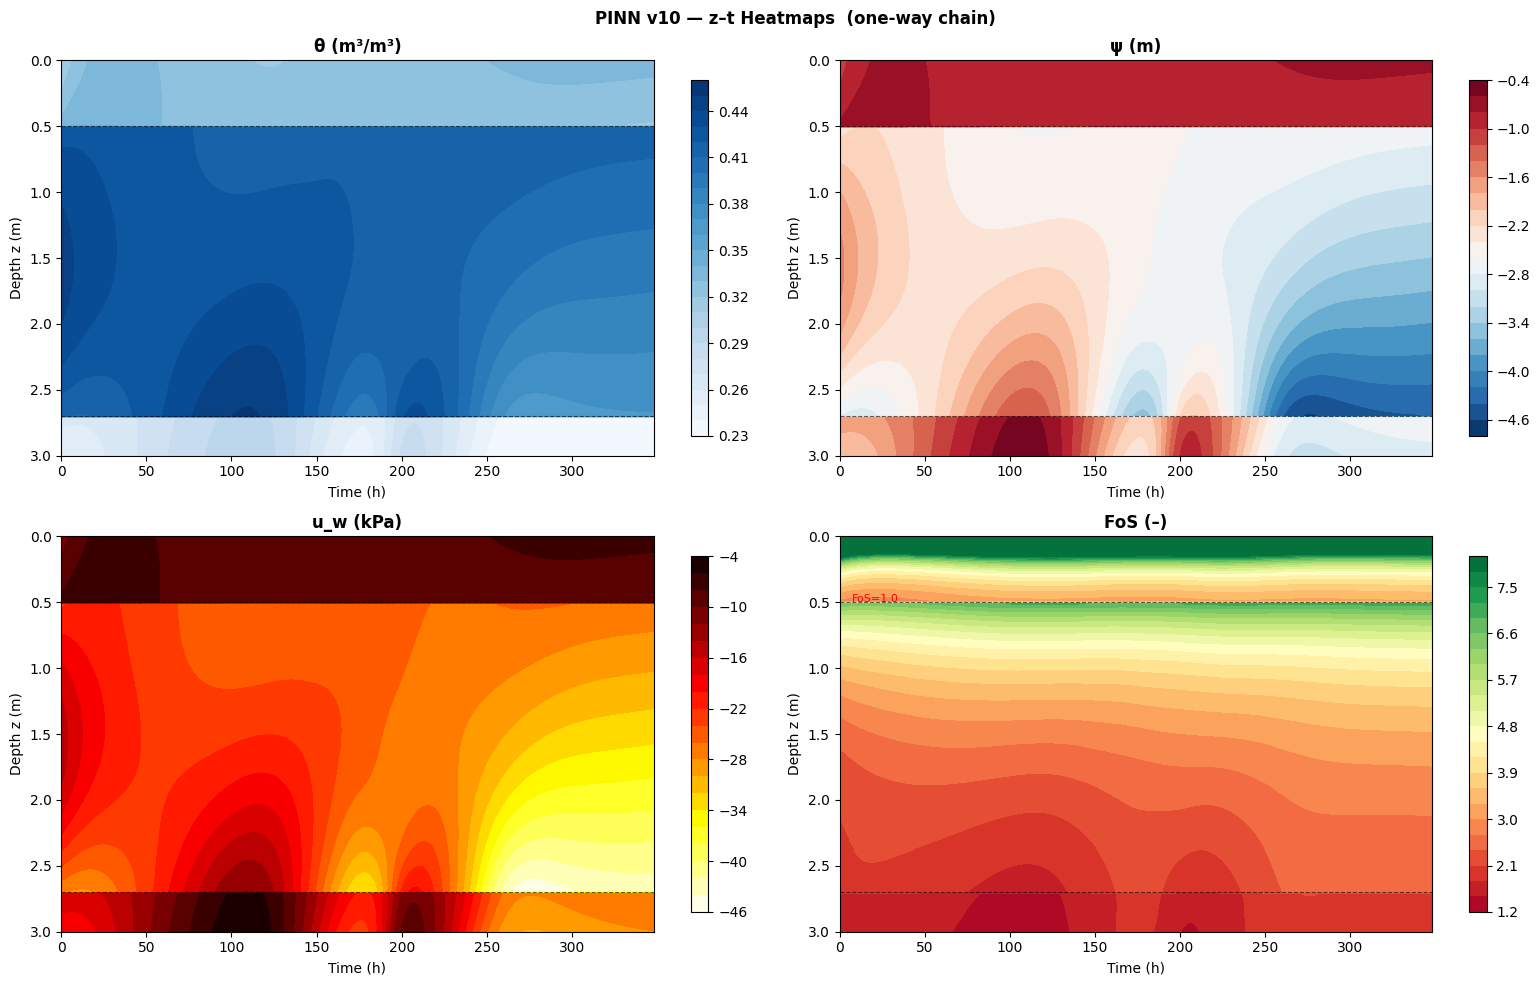


────────────────────────────────────────────────────────────────────
  FoS SENSITIVITY  t=348h
  Scenario        FoS_min  FoS_mean    %<1.0    Verdict
────────────────────────────────────────────────────────────────────
  Baseline          2.004     3.753     0.0%  stable ✓
  c′ −20%           1.957     3.539     0.0%  stable ✓
  c′ +20%           2.052     3.966     0.0%  stable ✓
  φ′ −20%           1.600     3.236     0.0%  stable ✓
  φ′ +20%           2.461     4.304     0.0%  stable ✓
  Both −20%         1.553     3.017     0.0%  stable ✓
  Both +20%         2.509     4.507     0.0%  stable ✓
────────────────────────────────────────────────────────────────────
[Plot] FoS sensitivity → fos_sensitivity_1d.png


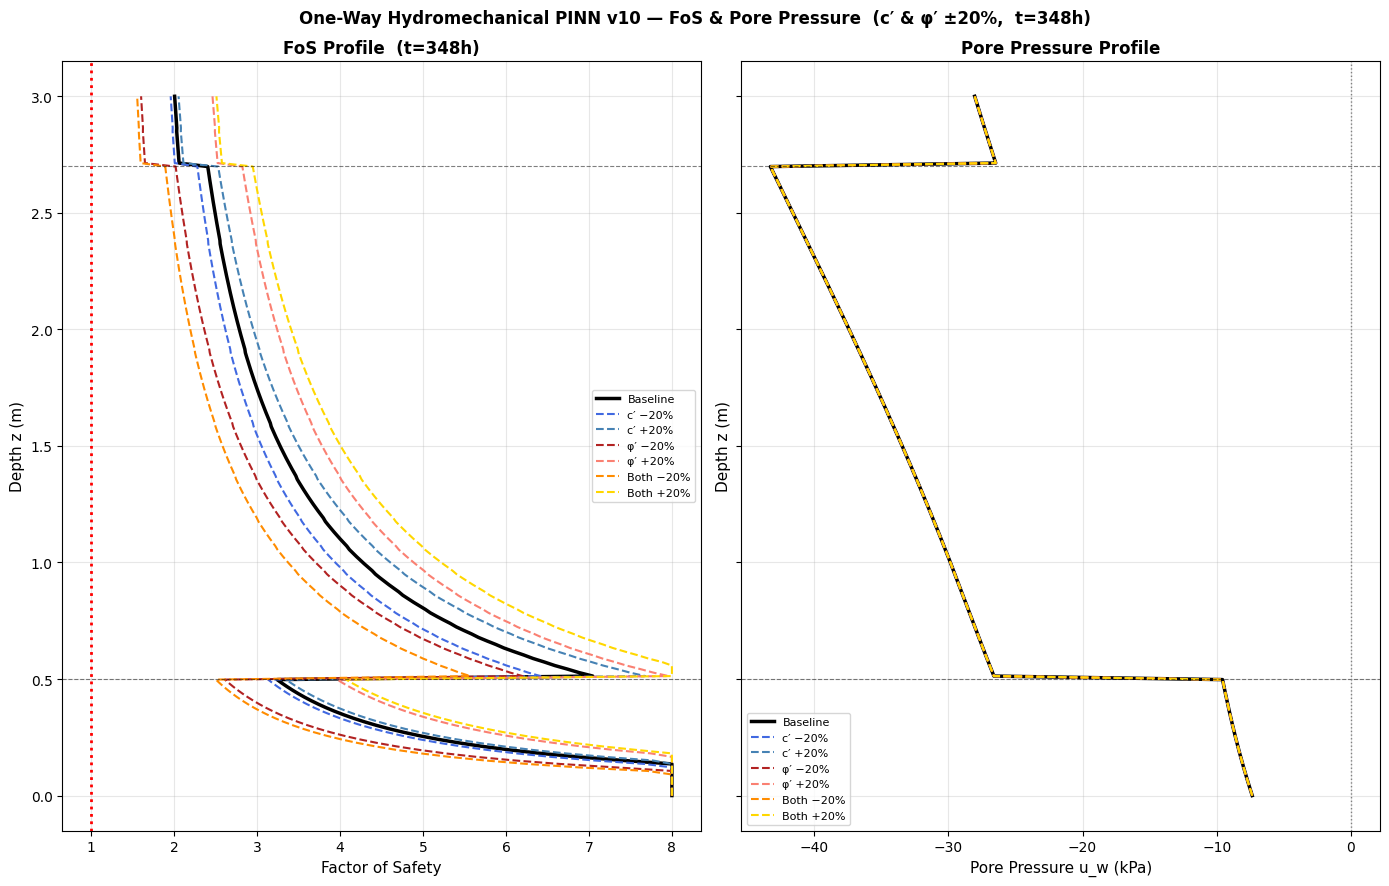


  STAGE 1 RESULTS
  Ensemble : 2/2 seeds retained
  R2 train : 0.8154 +/- 0.0012
  R2 val   : 0.0279 +/- 0.0289
  R2 test  : -12.9488 +/- 0.3940
  NSE test : -12.9488 +/- 0.3940
  RMSE test: 0.05920 +/- 0.00084 m3/m3
  Train-Test R2 gap: +13.7642  overfit warning
  EffSt active: 0.0% of Phase-2 steps

  Learned VG params (L1 — data-constrained):
    alpha      prior=5.900e-01  learned=5.400e-01  delta=-8.5%
    n          prior=1.480e+00  learned=1.845e+00  delta=+24.6%
    Ks         prior=1.220e-06  learned=1.632e-06  delta=+33.8%
    theta_r    prior=6.500e-02  learned=1.421e-01  delta=+118.6%
    theta_s    prior=4.300e-01  learned=3.000e-01  delta=-30.2%  <- AT BOUND

  Slope stability (Stage 1, t=T_MAX):  FoS_min=1.553  (stable across c/phi +/-20%)

  STAGE 2 — Rolling Window State Assimilation
  VG params : FROZEN from Stage 1 (material constants)
  Updates   : network weights only, per 24h window
  IC chain  : psi(z, t_end_W) -> IC for window W+1

  STAGE 2 — Rolling Window As

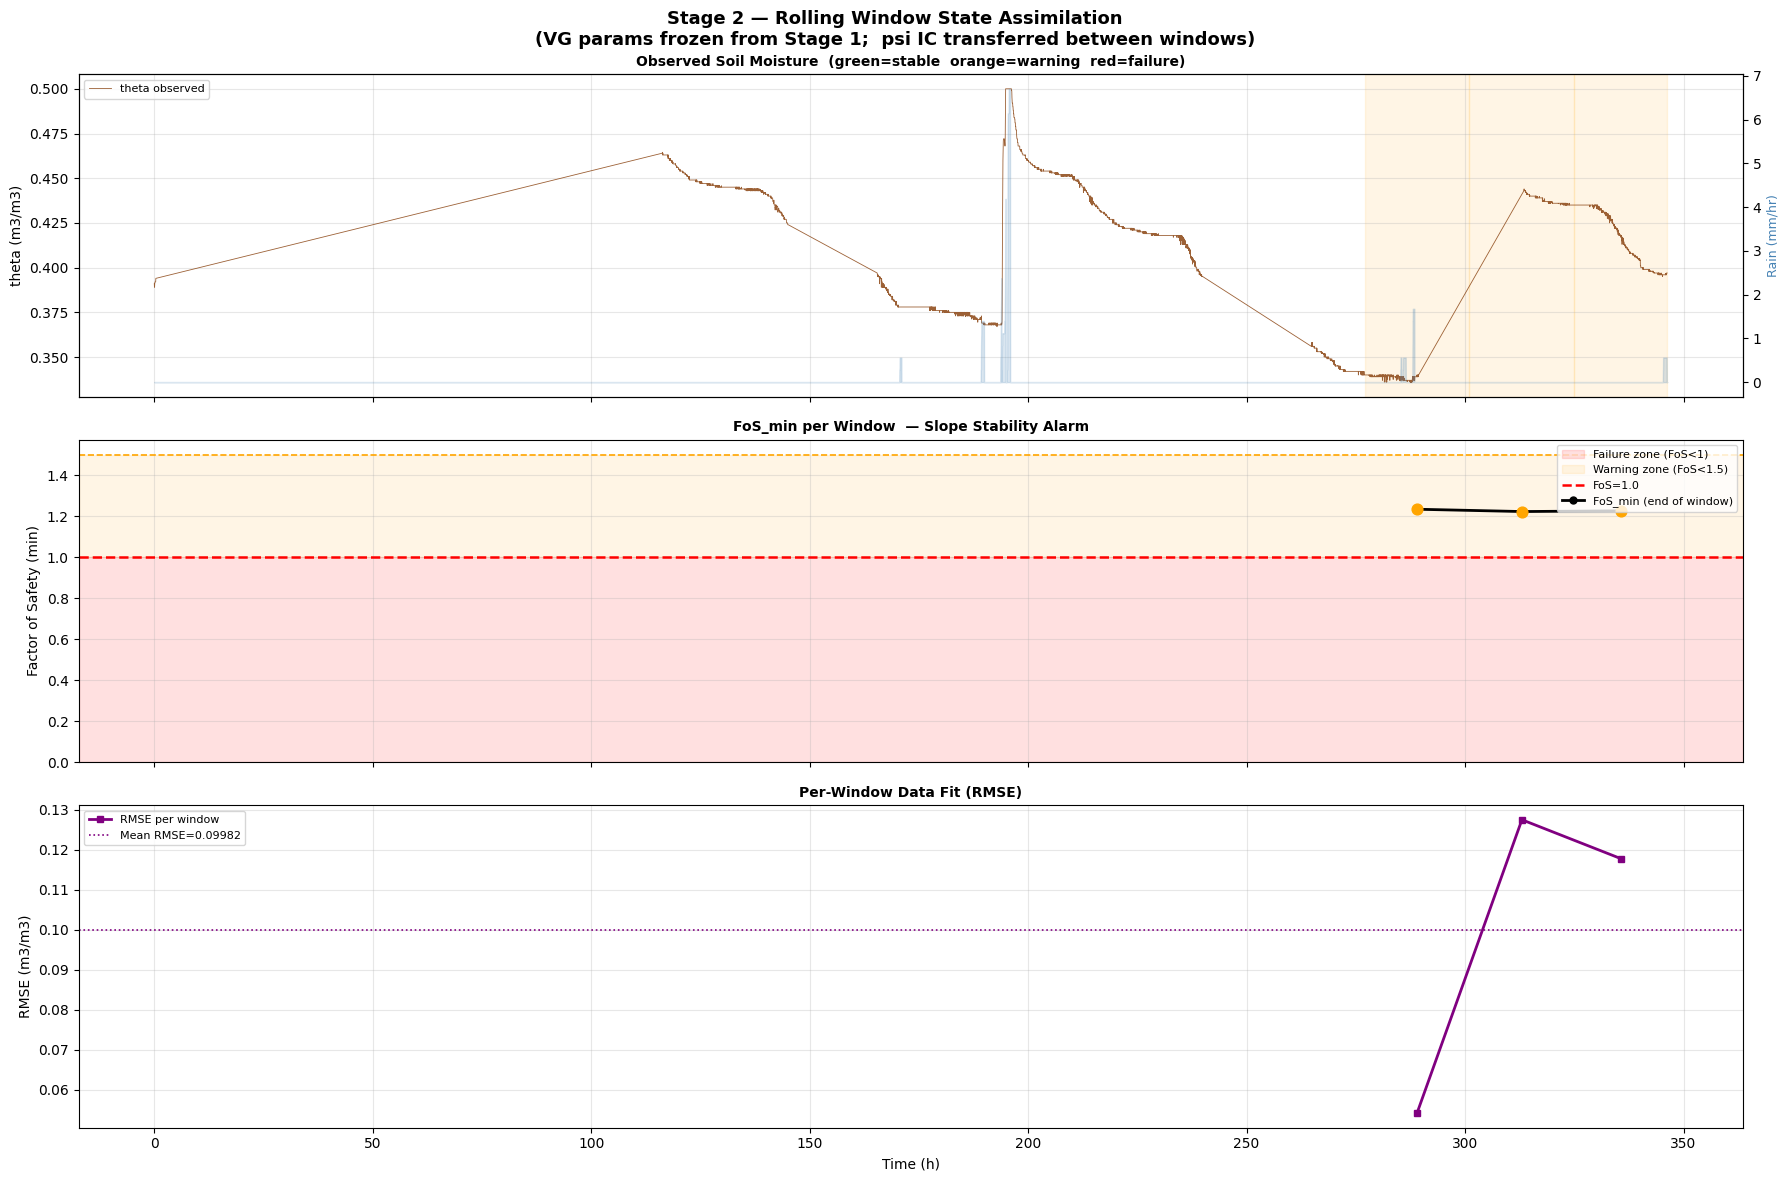


  COMBINED FINAL SUMMARY

  Stage 1 (physics discovery — temporal holdout):
    R2 test  = -12.9488   RMSE test = 0.05920 m3/m3
    VG params: validated on 10% held-out test window
    Scientific claim: Richards physics learned, not memorised

  Stage 2 (rolling assimilation — 3 x 24h windows):
    RMSE: mean=0.09982  max=0.12752 m3/m3
    FoS_min: mean=1.229  worst=1.224 (window 2: t=[301-325h])
    FoS < 1.5 warnings : 3 windows
    FoS < 1.0 failures : 0 windows

  OVERALL VERDICT: EARLY WARNING


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  PINN v10  —  1-D One-Way Hydromechanical  |  POST-REVIEW + v10 FIXES
#
#  FIXES vs v9
#  ─────────────────────────────────────────────────────────────────────
#  [v10-F1] CRITICAL: Gravity sign corrected in loss_richards (Richards PDE).
#           Coordinate system has z=0 at BASE and z=Z_MAX at SURFACE,
#           so z points UPWARD. Elevation head = z, therefore dz_ele/dz = +1.
#           The correct Darcy flux inner term is K*(dψ/dz + 1), NOT K*(dψ/dz - 1).
#           The v9 sign "-1" corresponded to a z-DOWN coordinate where gravity
#           opposes increasing z — the opposite of this model's convention.
#           Effect: Phase 2 Richards loss was forcing water to flow UP (out of
#           soil against gravity), directly explaining R² ≈ -42 collapse.
#
#           BEFORE (v9): inner = K * (dpsi_dz_phys - 1.0)   ← z-down sign, WRONG
#           AFTER (v10): inner = K * (dpsi_dz_phys + 1.0)   ← z-up sign, CORRECT
#
#  [v10-F2] CRITICAL: Top boundary condition flux corrected in loss_bc_top.
#           With z pointing UP, rainfall (downward flux) is negative in the
#           z-up convention. The surface Darcy condition is:
#               q_up = -K*(dψ/dz + 1) = -q_rain
#           which simplifies to:  K*(dψ/dz + 1) = q_rain
#           so q_pred should be K*(dψ/dz + 1) compared to q_rain (positive scalar).
#
#           BEFORE (v9): q_pred = -K * (dpsi_dz_phys - 1.0) = K*(1 - dψ/dz)  WRONG
#           AFTER (v10): q_pred =  K * (dpsi_dz_phys + 1.0)                   CORRECT
#
#  [v10-F3] CRITICAL: psi scale/shift in forward() corrected for Z_MAX=3.0m.
#           Previous values (L2: scale=7, shift=-3.5; L3: scale=20, shift=-10)
#           were inherited from the old 10m domain.  With Z_MAX=3m the L3
#           fallthrough gave psi in [-30, +10]m -- (alpha*psi)^n blows up,
#           VG gradients vanish, Richards loss flatlines entirely.
#           New values derived from physical psi bounds per layer:
#             L1 Sandy CL : scale=2.0, shift=-1.25  → psi in [-3.0, +0.5]m
#             L2 Clay     : scale=3.0, shift=-2.25  → psi in [-5.0, +0.5]m
#             L3 Saprolite: scale=1.5, shift=-0.75  → psi in [-2.0, +0.5]m
#
#  All v9 fixes (G2-G5, H1-H2, I1-I2, J1, M1-M2) are retained unchanged.
#  All v8 fixes (F1–F6) and v7 fixes (R1–R6) are retained unchanged.
# ═══════════════════════════════════════════════════════════════════════════

import os
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.autograd import grad as autograd_grad

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42

def set_seed(s):
    torch.manual_seed(s)
    np.random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = False
    print(f"[Device] GPU → {torch.cuda.get_device_name(0)}"
          f"  ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)"
          f"  CUDA {torch.version.cuda}  PyTorch {torch.__version__}")
else:
    print("[Device] CPU  (switch to T4 GPU in Colab for full speed)")

def gpu_mem_mb():
    if device.type != "cuda": return 0.0, 0.0
    return (torch.cuda.memory_allocated(0)/1e6,
            torch.cuda.memory_reserved(0)/1e6)

# ── Domain ────────────────────────────────────────────────────────────────
# [Q1] Z_MAX = 3.0m — models A+B horizons down to A/B–C boundary.
#
#      NST granite regolith slope failure mechanism (from literature):
#      - Failure plane = B/C horizon boundary (subsoil/saprolite contact)
#      - Typical depth: 1.5–3.0m on steep NST hillslopes
#      - Sichon District case study: slip within weathered granite layer
#      - Bedrock at 5–20m is BELOW the failure plane — not modelled here
#
#      Modelling only A+B horizons is physically correct:
#      - Pore pressure at the B/C boundary drives failure
#      - Sensor at 30cm (A horizon) → Richards propagates 1.2–2.7m to failure
#      - Saprolite (C horizon) acts as lower boundary condition (free drainage)
#
#      Adjust Z_MAX between 1.5–3.0m based on site investigation if available.
Z_MAX       = 3.0   # metres — A+B horizon depth to failure plane
T_MAX       = 24.0
SLOPE_ANGLE = 30.0  # degrees — adjust to your site measurement
RHO_W       = 1000.0
G_ACC       = 9.81

# ── CSV ───────────────────────────────────────────────────────────────────
# ┌─────────────────────────────────────────────────────────────────────┐
# │  PER-DATASET CONFIGURATION — update these for each sensor CSV       │
# │                                                                     │
# │  SENSOR_DEPTH_M : actual sensor depth from surface in metres.       │
# │                   Overrides COL_DEPTH when set (not None).          │
# │                   Dataset 105/108/109: sensor at 0.30m (30cm)       │
# │                                                                     │
# │  COL_DEPTH  : column fallback if SENSOR_DEPTH_M is None.            │
# │               Must contain numeric depth in metres, NOT temperature.│
# │                                                                     │
# │  DEPTH_POS_DOWN: True  → z_m = Z_MAX − depth  (z=0 at base)        │
# │                  False → z_m = depth           (z=0 at surface)     │
# │                                                                     │
# │  Coordinate system: z=0 at slope BASE, z=Z_MAX at SURFACE.          │
# │  Sensor at 30cm from surface → z_m = 3.0 − 0.30 = 2.70m → L1      │
# └─────────────────────────────────────────────────────────────────────┘
CSV_FILE         = "/content/105_pinn.csv"
COL_TIME         = "timestamp"
COL_DEPTH        = "geo"         # fallback only — overridden by SENSOR_DEPTH_M
COL_RAINFALL     = "rain"
COL_SOIL         = "soil"
RAINFALL_UNIT    = "mm/hr"
DEPTH_POS_DOWN   = True
# [P1] Sensor at 30cm from surface → z_m = 3.0 - 0.30 = 2.70m → L1 (A horizon)
SENSOR_DEPTH_M   = 0.30

LAYER_DATA_SUPPORT = {1: True, 2: False, 3: False}
LAYER_NAMES = {
    1: "Sandy CL / A-horizon (L1) [data-constrained — sensor z=2.70m]",
    2: "Clay B-horizon        (L2) [prior-constrained — pore pressure zone]",
    3: "Saprolite C-horizon   (L3) [prior-constrained — failure plane base]",
}

TIMESTAMP_FORMATS = [
    "%m/%d/%Y %H:%M", "%d/%m/%Y %H:%M", "%d/%m/%Y %H:%M:%S",
    "%d-%m-%Y %H:%M", "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S",
    "%m/%d/%Y %H:%M:%S",
]

# ── Soil layers ───────────────────────────────────────────────────────────
# NST granite regolith profile — A and B horizons only (z=0 at BASE=failure plane)
#
#   L1: z=2.7–3.0m  Sandy Clay Loam (A horizon, topsoil)
#                    ← sensor at z = 3.0 - 0.30 = 2.70m
#   L2: z=0.5–2.7m  Clay / Clay Loam (B horizon, kaolinite-rich red/yellow clay)
#                    ← dominates the profile, where pore pressure builds
#   L3: z=0.0–0.5m  Weathered granite / Saprolite (top of C horizon)
#                    ← failure plane zone; free-draining lower boundary
#
# VG parameters: Carsel & Parrish (1988) + tropical residual soil literature
# Geotechnical: typical values for kaolinitic tropical residual soils
SOIL = {
    1: dict(z_lo=2.7,  z_hi=3.0,
            theta_r=0.065, theta_s=0.430, alpha=0.59,  n=1.48,
            Ks=1.22e-6,  rho_b=1500.0,
            c_prime=5.0e3,  phi_prime=30.0),   # A horizon: Sandy Clay Loam
    2: dict(z_lo=0.5,  z_hi=2.7,
            theta_r=0.090, theta_s=0.480, alpha=0.19,  n=1.31,
            Ks=1.39e-7,  rho_b=1650.0,
            c_prime=12.0e3, phi_prime=24.0),   # B horizon: Clay (kaolinite)
    3: dict(z_lo=0.0,  z_hi=0.5,
            theta_r=0.068, theta_s=0.380, alpha=0.80,  n=1.89,
            Ks=3.64e-6,  rho_b=1750.0,
            c_prime=2.0e3,  phi_prime=32.0),   # C horizon top: Saprolite
            # Saprolite: higher Ks (fractured), lower cohesion, higher phi
            # Free drainage BC at z=0 (base of model domain)
}

THETA_CLIP_LO = 0.05
# [I2] Set to 0.50 — above Sandy Clay Loam saturation (~0.43) but below
# physically implausible values. Rejects sensor noise spikes.
THETA_CLIP_HI = 0.50

PARAM_BOUNDS = {
    # [P3] L1 is now data-constrained (sensor layer). Bounds widened for L1
    # to allow inverse learning; L3 bounds also kept wide from [G2].
    "alpha":   [(0.005, 2.0),  (0.01, 2.0),   (0.01, 1.0)],
    "n":       [(1.10,  2.50), (1.05, 1.80),  (1.01, 1.65)],
    "Ks":      [(1e-8,  1e-4), (1e-9, 1e-5),  (1e-11, 1e-5)],
    "theta_r": [(0.01,  0.15), (0.01, 0.15),  (0.05, 0.18)],
    "theta_s": [(0.30,  0.55), (0.30, 0.55),  (0.30, 0.55)],
}


# ═══════════════════════════════════════════════════════════════════════════
#  Layer-property helpers
# ═══════════════════════════════════════════════════════════════════════════

def _lp_fixed(z_norm, key):
    z_m  = z_norm * Z_MAX
    v1   = float(SOIL[1][key]); v2 = float(SOIL[2][key]); v3 = float(SOIL[3][key])
    return torch.where(z_m >= 2.7, v1*torch.ones_like(z_m),
           torch.where(z_m >= 0.5, v2*torch.ones_like(z_m),
                                   v3*torch.ones_like(z_m)))

def _lp_trainable(z_norm, key, params):
    z_m = z_norm * Z_MAX
    v1, v2, v3 = params[key][0], params[key][1], params[key][2]
    return torch.where(z_m >= 2.7, v1.expand_as(z_m),
           torch.where(z_m >= 0.5, v2.expand_as(z_m),
                                   v3.expand_as(z_m)))

def _lp(z, key, params=None):
    return _lp_trainable(z, key, params) if params is not None else _lp_fixed(z, key)


# ═══════════════════════════════════════════════════════════════════════════
#  Van Genuchten functions
# ═══════════════════════════════════════════════════════════════════════════

def vg_Se(psi, z, params=None):
    alpha = _lp(z, "alpha", params); n = _lp(z, "n", params)
    m     = 1.0 - 1.0/n
    arg   = torch.clamp(alpha*torch.abs(psi), min=0.0)
    Se    = 1.0/(1.0+arg.pow(n)).pow(m)
    Se    = torch.where(psi >= 0.0, torch.ones_like(psi), Se)
    return torch.clamp(Se, 1e-6, 1.0-1e-6)

def vg_K(psi, z, params=None):
    Ks = _lp(z, "Ks", params); n = _lp(z, "n", params)
    m  = 1.0 - 1.0/n
    Se = vg_Se(psi, z, params)
    inner = torch.clamp(1.0-torch.clamp(Se,1e-6,1-1e-6).pow(1.0/m), min=0.0)
    K     = Ks*Se.pow(0.5)*(1.0-inner.pow(m)).pow(2.0)
    return torch.clamp(K, 1e-15, 1e-2)

def dtheta_dpsi(psi, z, params=None):
    alpha = _lp(z, "alpha", params); n = _lp(z, "n", params)
    m     = 1.0 - 1.0/n
    dts   = _lp(z, "theta_s", params) - _lp(z, "theta_r", params)
    arg   = torch.clamp(alpha*torch.abs(psi), min=0.0)
    C     = dts*m*n*alpha*arg.pow(n-1.0)/(1.0+arg.pow(n)).pow(m+1.0)
    C     = torch.where(psi >= 0.0, torch.zeros_like(psi), C)
    return torch.clamp(C, 0.0, 10.0)


# ═══════════════════════════════════════════════════════════════════════════
#  One-way hydromechanical coupling chain
# ═══════════════════════════════════════════════════════════════════════════

def pore_pressure(psi):
    return torch.clamp(RHO_W * G_ACC * psi, -5e5, 5e5)

def overburden_stress(z_norm):
    z_m    = z_norm * Z_MAX
    N      = z_m.shape[0]
    n_q    = 20
    frac   = torch.linspace(0.0, 1.0, n_q, device=z_m.device).unsqueeze(0)
    z_int  = z_m * frac
    rho_at = _lp_fixed(z_int.reshape(-1,1)/Z_MAX,
                        "rho_b").reshape(N, n_q)
    sigma_v = rho_at.mean(dim=1, keepdim=True) * G_ACC * z_m
    return torch.clamp(sigma_v, min=0.0)

def compute_hydromech_chain(psi, z_norm, slope_rad):
    u_w     = pore_pressure(psi)
    sigma_v = overburden_stress(z_norm)
    cos2a   = np.cos(slope_rad)**2
    sincos  = np.sin(slope_rad)*np.cos(slope_rad)
    sp_n    = torch.clamp(sigma_v*cos2a - u_w, min=0.0)
    tau     = sigma_v*sincos + 1e-3
    c_p     = _lp(z_norm, "c_prime")
    phi_p   = _lp(z_norm, "phi_prime")*(np.pi/180.0)
    fos     = torch.clamp((c_p + sp_n*torch.tan(phi_p))/tau, 0.0, 20.0)
    return u_w, sigma_v, sp_n, tau, fos


# ═══════════════════════════════════════════════════════════════════════════
#  Neural Network
# ═══════════════════════════════════════════════════════════════════════════

def _softplus_inv(y):
    y_np = np.asarray(y, dtype=np.float64)
    return float(np.log(np.expm1(np.clip(y_np, 1e-6, None)) + 1e-10))


class PINN(nn.Module):
    def __init__(self, hidden=6, width=128):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(hidden-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        self.trunk    = nn.Sequential(*layers)
        self.head_psi = nn.Linear(width, 1)
        # head_theta removed — theta derived from psi via VG retention curve
        # theta = theta_r + (theta_s-theta_r)*Se(psi)  [v10-F4]
        self._init_weights()

        def _ip(key):
            return nn.Parameter(torch.tensor(
                [SOIL[i][key] for i in [1,2,3]], dtype=torch.float32))
        self._log_alpha   = nn.Parameter(torch.log(_ip("alpha").data))
        self._log_Ks      = nn.Parameter(torch.log(_ip("Ks").data))
        self._raw_n       = nn.Parameter(_ip("n").data - 1.0)
        self._raw_theta_r = nn.Parameter(_ip("theta_r").data)
        self._raw_theta_s = nn.Parameter(_ip("theta_s").data)

        print("\n[PINN v10 — 1-D One-Way Hydromechanical | v10 Fixes Applied]")
        print("  Inputs  : (z_norm, t_norm)")
        print("  Outputs : psi (network head);  theta via VG(psi)  [v10-F4]")
        print("  Chain   : Richards → u_w → σ′_n → FoS  (one-way)")
        print("  v10 Fix : [v10-F1] gravity sign  [v10-F2] BC_top flux  [v10-F3] psi scale/shift")
        print("            [v10-F4] theta coupled to psi via VG retention curve (head_theta removed)")
        print("            [v10-F3] ψ scale/shift corrected for 3m domain (L3 was scale=20→1.5)")
        print("  v9 Fixes: theta_s[I1], clip_hi[I2], bounds[G2,G3], prior_dc[G4], Ks_lr[G5], ES[H1,H2], ph2_ramp[M1,M2]")
        print("  v8 Fixes: K_s lr, θ_r bound, lam_h, lam_bc, smoothness, colloc pts")
        print("  v7 Fixes: NaN recovery, n-bound, θ_r tightened, seed exclusion, EffSt")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    @property
    def hydro_params(self):
        alpha   = torch.exp(self._log_alpha)
        Ks      = torch.exp(self._log_Ks)

        n_raw = 1.0 + F.softplus(self._raw_n)
        n_lo  = torch.tensor([PARAM_BOUNDS["n"][i][0] for i in range(3)],
                              dtype=torch.float32, device=self._raw_n.device)
        n_hi  = torch.tensor([PARAM_BOUNDS["n"][i][1] for i in range(3)],
                              dtype=torch.float32, device=self._raw_n.device)
        n = torch.max(torch.min(n_raw, n_hi), n_lo)

        theta_r = torch.clamp(self._raw_theta_r, 0.01, 0.25)
        theta_s = torch.clamp(self._raw_theta_s, 0.10, 0.65)
        theta_s = torch.max(theta_s, theta_r.detach()+0.05)
        return {"alpha": alpha, "n": n, "Ks": Ks,
                "theta_r": theta_r, "theta_s": theta_s}

    def clamp_params_(self):
        with torch.no_grad():
            for li in range(3):
                lo,hi = PARAM_BOUNDS["alpha"][li]
                self._log_alpha.data[li].clamp_(np.log(lo), np.log(hi))
                lo,hi = PARAM_BOUNDS["Ks"][li]
                self._log_Ks.data[li].clamp_(np.log(lo), np.log(hi))

                lo, hi = PARAM_BOUNDS["n"][li]
                raw_lo = _softplus_inv(lo - 1.0)
                raw_hi = _softplus_inv(hi - 1.0)
                self._raw_n.data[li].clamp_(raw_lo, raw_hi)

                lo,hi = PARAM_BOUNDS["theta_r"][li]
                self._raw_theta_r.data[li].clamp_(lo, hi)
                lo,hi = PARAM_BOUNDS["theta_s"][li]
                self._raw_theta_s.data[li].clamp_(lo, hi)

    def get_learned_params(self):
        return {k: v.detach().cpu().numpy() for k,v in self.hydro_params.items()}

    def forward(self, z, t):
        feat  = self.trunk(torch.cat([z, t], dim=1))
        z_m   = z * Z_MAX
        raw_psi = self.head_psi(feat)
        # [v10-F3] scale/shift values corrected for Z_MAX=3.0m domain.
        # Previous values (scale=7/20, shift=-3.5/-10) were inherited from the
        # old 10m domain.  With Z_MAX=3m the fallthrough L3 case gave
        # ψ ∈ [−30, +10]m, which sends VG's (αψ)^n to near-infinity and
        # zeroes all gradients — physically insane and numerically fatal.
        #
        # New values derived from physical ψ bounds per layer:
        #   L1 Sandy CL  (z=2.7–3.0m): ψ ∈ [−3.0, +0.5]m → scale=2.0, shift=−1.25
        #   L2 Clay      (z=0.5–2.7m): ψ ∈ [−5.0, +0.5]m → scale=3.0, shift=−2.25
        #   L3 Saprolite (z=0.0–0.5m): ψ ∈ [−2.0, +0.5]m → scale=1.5, shift=−0.75
        # IC (ψ_0=−(Z_MAX−z)·0.4) sits inside all windows: L1≈−0.06, L2≈−0.56, L3≈−1.1m
        scale   = torch.where(z_m >= 2.7,  2.0*torch.ones_like(z_m),
                  torch.where(z_m >= 0.5,  3.0*torch.ones_like(z_m),
                                            1.5*torch.ones_like(z_m)))
        shift   = torch.where(z_m >= 2.7, -1.25*torch.ones_like(z_m),
                  torch.where(z_m >= 0.5, -2.25*torch.ones_like(z_m),
                                          -0.75*torch.ones_like(z_m)))
        psi = scale*torch.tanh(raw_psi) + shift
        p       = self.hydro_params
        theta_r = _lp(z, "theta_r", p)
        theta_s = _lp(z, "theta_s", p)
        # [v10-F4] theta derived from psi through VG retention curve.
        # Se = 1/(1+(alpha*|psi|)^n)^m for psi<0, Se=1 for psi>=0.
        # This couples the two outputs mathematically: the network cannot
        # predict a wet theta while simultaneously predicting a dry psi.
        Se      = vg_Se(psi, z, p)
        theta_d = theta_r + (theta_s - theta_r) * Se
        return psi, theta_d


# ═══════════════════════════════════════════════════════════════════════════
#  Collocation sampling
# ═══════════════════════════════════════════════════════════════════════════

_rain_cdf = None

def build_rain_sampler(t_rain_h, q_rain_ms):
    global _rain_cdf
    t_n = (t_rain_h.cpu().numpy()/T_MAX).astype(np.float64)
    q   = q_rain_ms.cpu().numpy().astype(np.float64)
    w   = q + 0.05*q.max()
    cdf = np.cumsum(w); cdf /= cdf[-1]
    _rain_cdf = (t_n, cdf)
    print(f"  [Sampler] Rain importance CDF over {len(t_n)} pts")

def _importance_t(n):
    if _rain_cdf is None:
        return torch.rand(n, 1, device=device)
    t_arr, cdf = _rain_cdf
    t_s = np.interp(np.random.rand(n), cdf, t_arr).astype(np.float32)
    return torch.tensor(t_s, device=device).unsqueeze(1)

def sample_pts(n_int, n_bc, n_ic, use_importance=True):
    def rn(n): return torch.rand(n, 1, device=device)
    def ze(n): return torch.zeros(n, 1, device=device)
    def on(n): return torch.ones(n, 1, device=device)
    def rt(n): return _importance_t(n) if use_importance else rn(n)
    def rq(*ts): return tuple(t.requires_grad_(True) for t in ts)
    return dict(
        int=rq(rn(n_int), rt(n_int)),
        ic =rq(rn(n_ic),  ze(n_ic)),
        top=rq(ze(n_bc),  rt(n_bc)),
        bot=rq(on(n_bc),  rt(n_bc)),
    )

def psi_initial(z_norm):
    z_phys = z_norm * Z_MAX
    return -(Z_MAX - z_phys) * 0.4

_q_rain_fn = None

def get_q_rain():
    if _q_rain_fn is None:
        raise RuntimeError(
            "[get_q_rain] Rainfall function not set.\n"
            "  CSV must be loaded before training.")
    return _q_rain_fn


# ═══════════════════════════════════════════════════════════════════════════
#  Gradient helper
# ═══════════════════════════════════════════════════════════════════════════

def _grad(y, v):
    return autograd_grad(y, v, grad_outputs=torch.ones_like(y),
                         create_graph=True, retain_graph=True)[0]

def safe_sq(res, name=""):
    val = torch.mean(res**2)
    if not torch.isfinite(val):
        print(f"  ⚠  NaN/Inf in '{name}'")
        return torch.tensor(0.0, device=device, requires_grad=True)
    return val


# ═══════════════════════════════════════════════════════════════════════════
#  Physics losses
# ═══════════════════════════════════════════════════════════════════════════

def loss_richards(model, z, t):
    """
    Richards equation residual.

    Coordinate system: z=0 at BASE, z=Z_MAX at SURFACE (z points UP).
    Elevation head  = z  →  dz_ele/dz = +1
    Total head      H = ψ + z
    Darcy flux (upward+): q = −K · dH/dz = −K · (dψ/dz + 1)
    Continuity:  C · dψ/dt = −dq/dz = d/dz[ K · (dψ/dz + 1) ]

    [v10-F1] Sign corrected: inner term is K*(dψ/dz + 1), NOT K*(dψ/dz − 1).
    The "−1" in v9 was the z-DOWN gravity convention and caused Phase-2
    to drive water upward, collapsing test R² to −42.
    """
    p      = model.hydro_params
    psi, _ = model(z, t)
    K      = vg_K(psi, z, p)
    C      = dtheta_dpsi(psi, z, p)
    T_MAX_S      = T_MAX * 3600.0
    dpsi_dz_phys = _grad(psi, z) / Z_MAX
    dpsi_dt_phys = _grad(psi, t) / T_MAX_S
    # [v10-F1] CORRECTED: +1.0 (z-up gravity), was -1.0 (z-down, WRONG)
    inner     = K * (dpsi_dz_phys + 1.0)
    dinner_dz = _grad(inner, z) / Z_MAX
    res       = C * dpsi_dt_phys - dinner_dz
    dc_layer  = [k for k, v in LAYER_DATA_SUPPORT.items() if v][0]
    Ks_ref    = float(SOIL[dc_layer]["Ks"])   # 1.22e-6 m/s for Sandy CL L1
    return safe_sq(res / Ks_ref, "richards")


def loss_effective_stress_equilibrium(model, z, t):
    psi, _       = model(z, t)
    dpsi_dz_phys = _grad(psi, z) / Z_MAX
    # [v10-F1] consistent sign: super-hydrostatic means dψ/dz + 1 > something
    # The physical check is still: upward flux exceeds gravity drainage.
    # We penalise dψ/dz > 0 (upward psi gradient beyond hydrostatic).
    excess       = torch.clamp(dpsi_dz_phys - 1.0, min=0.0)
    loss_val     = safe_sq(excess, "eff_stress")
    was_active   = (excess.detach().abs().max().item() > 1e-8)
    return loss_val, was_active


def loss_ic(model, z, t):
    psi, _ = model(z, t)
    psi_0  = psi_initial(z)
    return safe_sq((psi - psi_0) / (Z_MAX + 1e-6), "ic_psi")


def loss_bc_top(model, z, t):
    """
    Top boundary condition at z = Z_MAX (soil surface).

    With z pointing UP, rainfall enters downward → negative flux in z-up sign.
    Surface Darcy balance:
        q_up = −K·(dψ/dz + 1) = −q_rain   (rain is positive mm/hr scalar)
    Rearranged:
        K·(dψ/dz + 1) = q_rain

    [v10-F2] CORRECTED: q_pred = K*(dψ/dz + 1), was −K*(dψ/dz − 1) = K*(1−dψ/dz) (WRONG).
    """
    p            = model.hydro_params
    psi, _       = model(z, t)
    K            = vg_K(psi, z, p)
    dpsi_dz_phys = _grad(psi, z) / Z_MAX
    # [v10-F2] CORRECTED: +1.0 and positive K, was -K*(dpsi_dz_phys - 1.0)
    q_pred       = K * (dpsi_dz_phys + 1.0)
    q_rain       = get_q_rain()(t)
    dc_layer     = [k for k, v in LAYER_DATA_SUPPORT.items() if v][0]
    Ks_ref       = float(SOIL[dc_layer]["Ks"])
    return safe_sq((q_pred - q_rain) / Ks_ref, "bc_top")


def loss_bc_bot(model, z, t):
    psi, _ = model(z, t)
    return safe_sq(psi/Z_MAX, "bc_bot")


def loss_smoothness(model, z, t, w_z=0.02):
    psi, _    = model(z, t)
    dpsi_dz   = _grad(psi, z) / Z_MAX
    d2psi_dz2 = _grad(dpsi_dz, z) / Z_MAX
    return w_z * safe_sq(d2psi_dz2, "smooth_z")


def loss_data(model, z_obs, t_obs, theta_obs):
    p          = model.hydro_params
    _, theta_d = model(z_obs, t_obs)
    dts        = _lp(z_obs, "theta_s", p) - _lp(z_obs, "theta_r", p)
    return safe_sq((theta_d - theta_obs)/(dts+1e-6), "data")


def loss_prior(model, lam_nc=0.2, lam_dc=0.001):
    # [G4] lam_dc reduced 0.01 → 0.001 to let data loss dominate for L3
    p    = model.hydro_params
    loss = torch.tensor(0.0, device=device)
    for li, li1 in enumerate([1,2,3]):
        lam = lam_nc if not LAYER_DATA_SUPPORT[li1] else lam_dc
        for key in ["alpha","n","Ks","theta_r","theta_s"]:
            prior = torch.tensor(SOIL[li1][key], dtype=torch.float32, device=device)
            loss  = loss + lam*((p[key][li]-prior)/(prior.abs()+1e-10))**2
    return loss


# ═══════════════════════════════════════════════════════════════════════════
#  Metrics
# ═══════════════════════════════════════════════════════════════════════════

def compute_metrics(model, z_obs, t_obs, theta_obs, label=""):
    with torch.no_grad():
        _, theta_d = model(z_obs, t_obs)
        obs_mean   = theta_obs.mean()
        ss_res = torch.sum((theta_d-theta_obs)**2)
        ss_tot = torch.sum((theta_obs-obs_mean)**2)
        rmse = torch.sqrt(torch.mean((theta_d-theta_obs)**2)).item()
        mae  = torch.mean(torch.abs(theta_d-theta_obs)).item()
        min_ss_tot = len(theta_obs) * (0.005 ** 2)
        if ss_tot.item() < min_ss_tot:
            r2  = float("nan")
            nse = float("nan")
        else:
            r2  = (1.0 - ss_res/ss_tot).item()
            nse = (1.0 - ss_res/ss_tot).item()
    return {"R2": r2, "NSE": nse, "RMSE": rmse, "MAE": mae, "set": label}

def _fmt_r2(v):
    """Format R² safely — returns 'NaN*' when signal is flat."""
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return "NaN*"
    return f"{v:.4f}"


# ═══════════════════════════════════════════════════════════════════════════
#  Data diagnosis
# ═══════════════════════════════════════════════════════════════════════════

def diagnose_data(loader, train_frac=0.80, val_frac=0.10):
    df  = loader.df
    t   = df["t_h"].values
    th  = df["theta"].values

    cut_tr  = np.quantile(t, train_frac)
    cut_val = np.quantile(t, train_frac + val_frac)

    tr_mask  = t <= cut_tr
    val_mask = (t > cut_tr) & (t <= cut_val)
    te_mask  = t > cut_val

    th_tr  = th[tr_mask]
    th_val = th[val_mask]
    th_te  = th[te_mask]

    print("\n  ══ DATA DIAGNOSIS (chronological 80/10/10) ══════════════════")
    print(f"  Train  θ: mean={th_tr.mean():.4f}  std={th_tr.std():.4f}"
          f"  range=[{th_tr.min():.4f},{th_tr.max():.4f}]"
          f"  t=[0–{cut_tr:.0f}h]  n={len(th_tr)}")
    print(f"  Val    θ: mean={th_val.mean():.4f}  std={th_val.std():.4f}"
          f"  range=[{th_val.min():.4f},{th_val.max():.4f}]"
          f"  t=[{cut_tr:.0f}–{cut_val:.0f}h]  n={len(th_val)}")
    print(f"  Test   θ: mean={th_te.mean():.4f}  std={th_te.std():.4f}"
          f"  range=[{th_te.min():.4f},{th_te.max():.4f}]"
          f"  t=[{cut_val:.0f}–{t.max():.0f}h]  n={len(th_te)}")

    drift_val  = abs(th_val.mean() - th_tr.mean())
    drift_test = abs(th_te.mean()  - th_tr.mean())
    range_ok   = (th_val.max()-th_val.min()) > 0.01

    print(f"\n  Val  drift from Train mean : {drift_val:.4f} m³/m³  "
          f"{'⚠ expected — future unseen period' if drift_val>0.02 else '✓ OK'}")
    print(f"  Test drift from Train mean : {drift_test:.4f} m³/m³  "
          f"{'⚠ expected — future unseen period' if drift_test>0.02 else '✓ OK'}")
    print(f"  Val θ range adequate       : {'✓' if range_ok else '⚠ TOO NARROW'}")

    if drift_test > 0.05:
        print(f"\n  ⚠  Large test drift detected ({drift_test:.4f} m³/m³).")
        print(f"     This is a real physical finding: the test window contains a")
        print(f"     wetting event not seen during training.  The temporal split")
        print(f"     is correct — the model must extrapolate using Richards physics.")
    else:
        print(f"\n  ✓  Drift within acceptable range for temporal split.")

    print(f"\n  ✓  Chronological split — no temporal leakage.")
    print(f"     Train → Val → Test move strictly forward in time.")

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    axes[0].plot(t, th, lw=0.5, color="saddlebrown", alpha=0.8, label="θ observed")
    axes[0].axvspan(0,        cut_tr,  alpha=0.08, color="steelblue", label=f"Train (0–{cut_tr:.0f}h)")
    axes[0].axvspan(cut_tr,   cut_val, alpha=0.08, color="orange",    label=f"Val ({cut_tr:.0f}–{cut_val:.0f}h)")
    axes[0].axvspan(cut_val,  t.max(), alpha=0.08, color="red",       label=f"Test ({cut_val:.0f}–{t.max():.0f}h)")
    axes[0].axvline(cut_tr,  color="orange", ls="--", lw=2)
    axes[0].axvline(cut_val, color="red",    ls="--", lw=2)
    axes[0].axhline(th_tr.mean(),  color="steelblue", ls=":", lw=1.2, label=f"Train mean={th_tr.mean():.4f}")
    axes[0].axhline(th_val.mean(), color="orange",    ls=":", lw=1.2, label=f"Val mean={th_val.mean():.4f}")
    axes[0].axhline(th_te.mean(),  color="red",       ls=":", lw=1.2, label=f"Test mean={th_te.mean():.4f}")
    axes[0].set_xlabel("Time (h)"); axes[0].set_ylabel("θ (m³/m³)")
    axes[0].set_title("Chronological split — Train | Val | Test  (80/10/10)",
                      fontweight="bold")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    rain = df["q_ms"].values*3.6e6
    axes[1].fill_between(t, rain, alpha=0.5, color="steelblue")
    axes[1].axvspan(0,        cut_tr,  alpha=0.08, color="steelblue")
    axes[1].axvspan(cut_tr,   cut_val, alpha=0.08, color="orange")
    axes[1].axvspan(cut_val,  t.max(), alpha=0.08, color="red")
    axes[1].axvline(cut_tr,  color="orange", ls="--", lw=2, label=f"Train/Val t={cut_tr:.0f}h")
    axes[1].axvline(cut_val, color="red",    ls="--", lw=2, label=f"Val/Test  t={cut_val:.0f}h")
    axes[1].set_xlabel("Time (h)"); axes[1].set_ylabel("Rainfall (mm/hr)")
    axes[1].set_title("Rainfall with chronological split markers", fontweight="bold")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("data_diagnosis.png", dpi=150, bbox_inches="tight")
    print(f"\n  [Plot] Data diagnosis → data_diagnosis.png")
    plt.show()

    return {"drift_val": drift_val, "drift_test": drift_test}


# ═══════════════════════════════════════════════════════════════════════════
#  Data split
# ═══════════════════════════════════════════════════════════════════════════

def make_split(z_obs, t_obs, theta_obs, train_frac=0.80, val_frac=0.10):
    t_np    = t_obs.cpu().numpy().flatten()
    dev     = z_obs.device
    cut_tr  = np.quantile(t_np, train_frac)
    cut_val = np.quantile(t_np, train_frac + val_frac)
    tr_mask  = torch.tensor(t_np <= cut_tr,                       device=dev)
    val_mask = torch.tensor((t_np > cut_tr) & (t_np <= cut_val), device=dev)
    te_mask  = torch.tensor(t_np > cut_val,                       device=dev)
    def s(mask):
        return tuple(v[mask].contiguous() for v in [z_obs, t_obs, theta_obs])
    return s(tr_mask), s(val_mask), s(te_mask)


# ═══════════════════════════════════════════════════════════════════════════
#  Training
# ═══════════════════════════════════════════════════════════════════════════

def train_single(seed,
                 warmup_epochs=3000,
                 total_epochs=10000,
                 lr=5e-4,
                 n_int=500,
                 n_bc=300,
                 n_ic=400,
                 lam_h=0.5,
                 lam_eff=0.0,   # [v10-F5] disabled — penalises valid wetting fronts in z-up coords (see note below)
                 lam_ic=0.1,
                 lam_bc=0.1,
                 lam_data=100.0,
                 lam_prior_nc=0.2,
                 lam_prior_dc=0.001,  # [G4] reduced from 0.01 → 0.001
                 warmup_r2_gate=0.60,
                 early_stop_patience=4000,  # [H1/H2] restored
                 early_stop_delta=1e-5,
                 csv_loader=None,
                 print_every=500,
                 cache_clear_every=1000,
                 verbose=True,
                 max_nan_recoveries=3):
    global _q_rain_fn
    set_seed(seed)
    slope_rad = SLOPE_ANGLE*np.pi/180.0
    model     = PINN(hidden=6, width=128).to(device)

    net_params   = (list(model.trunk.parameters()) +
                    list(model.head_psi.parameters()))

    # [G5] Ks lr multiplier raised to 1.0
    Ks_params   = [model._log_Ks]
    other_hydro = [model._log_alpha, model._raw_n,
                   model._raw_theta_r, model._raw_theta_s]

    opt = torch.optim.Adam([
        {"params": net_params,  "lr": lr,      "weight_decay": 1e-5},
        {"params": Ks_params,   "lr": lr*1.0,  "weight_decay": 0.0},  # [G5]
        {"params": other_hydro, "lr": lr*0.1,  "weight_decay": 0.0},
    ])

    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                opt, T_0=2000, T_mult=2, eta_min=1e-6)

    if csv_loader is None or not getattr(csv_loader, "_loaded", False):
        raise RuntimeError(
            "\n  [train_single] csv_loader is None or not loaded.\n"
            "  This model requires real sensor data.")

    csv_loader.to(device)
    zo_all     = csv_loader.z_obs_norm
    to_all     = csv_loader.t_obs_norm
    tho_all    = csv_loader.theta_obs
    _q_rain_fn = csv_loader.make_q_rain_fn()

    (zo_tr, to_tr, tho_tr), \
    (zo_val, to_val, tho_val), \
    (zo_te,  to_te,  tho_te)  = make_split(zo_all, to_all, tho_all)

    N_tr = len(tho_tr)
    # [J1] Compute val std once
    val_std = tho_val.cpu().numpy().flatten().std()
    val_es_reliable = (val_std > 0.015)
    if verbose:
        th_np    = tho_tr.cpu().numpy().flatten()
        th_val_np= tho_val.cpu().numpy().flatten()
        th_te_np = tho_te.cpu().numpy().flatten()
        drift_v  = abs(th_val_np.mean() - th_np.mean())
        drift_t  = abs(th_te_np.mean()  - th_np.mean())
        print(f"\n  ── Data split (TEMPORAL 80/10/10) ──────────────────────")
        print(f"  Train : {N_tr:>6} pts  θ_mean={th_np.mean():.4f}  θ_std={th_np.std():.4f}"
              f"  range=[{th_np.min():.4f},{th_np.max():.4f}]")
        print(f"  Val   : {len(tho_val):>6} pts  θ_mean={th_val_np.mean():.4f}"
              f"  drift={drift_v:.4f} m³/m³  {'✓ OK' if drift_v<0.01 else '⚠ SHIFT'}"
              f"  std={val_std:.4f}")
        print(f"  Test  : {len(tho_te):>6} pts  θ_mean={th_te_np.mean():.4f}"
              f"  drift={drift_t:.4f} m³/m³  {'✓ OK' if drift_t<0.01 else '⚠ SHIFT'}")
        if not val_es_reliable:
            print(f"  ⚠  Val std={val_std:.4f} < 0.015 — val window is near-flat.")
            print(f"     RMSE-based early stopping disabled: Phase 2 runs to full patience.")
            print(f"     R² on this val window will be negative by construction; use RMSE.")

        naive_val_rmse  = float(np.sqrt(np.mean((th_np.mean() - th_val_np)**2)))
        naive_test_rmse = float(np.sqrt(np.mean((th_np.mean() - th_te_np)**2)))
        print(f"\n  ── Naive baseline (predict train mean={th_np.mean():.4f}) ──")
        print(f"  Val  RMSE={naive_val_rmse:.5f}  ← Phase 2 must beat this")
        print(f"  Test RMSE={naive_test_rmse:.5f}")

    hist        = defaultdict(list)
    param_hist  = defaultdict(list)

    nan_count        = 0
    seed_failed      = False

    best_val_rmse = np.inf
    best_val_r2   = -np.inf
    best_sd       = None
    no_improve    = 0
    phase2_start   = warmup_epochs
    phase2_entered = False

    effst_active_count = 0
    effst_check_count  = 0

    if verbose:
        bar = "─"*165
        print(f"\n{bar}")
        print(f"{'Ep':>6} {'Ph':>3} {'Total':>10} {'Data':>10} {'Prior':>8} "
              f"{'Rich':>9} {'EffSt':>9} {'IC':>8} {'BC':>8} {'Smooth':>9} "
              f"{'R²_tr':>8} {'R²_val':>9} {'RMSE_val':>10} {'ES':>14}")
        print(bar)

    for ep in range(1, total_epochs+1):
        opt.zero_grad()

        if ep <= phase2_start:
            phase = 1
        else:
            if not phase2_entered:
                m_gate = compute_metrics(model, zo_tr, to_tr, tho_tr, "gate")
                if m_gate["R2"] < warmup_r2_gate:
                    phase2_start += warmup_epochs
                    print(f"\n  [Gate] Phase-1 R²={m_gate['R2']:.4f} < {warmup_r2_gate}"
                          f" → extending warmup to ep {phase2_start}")
                    phase = 1
                else:
                    phase2_entered = True
                    print(f"\n  [Gate] Phase-1 R²={m_gate['R2']:.4f} ≥ {warmup_r2_gate}"
                          f" ✓ → entering Phase 2")
                    # [H1] Reset early-stopping state on Phase-2 entry.
                    no_improve    = 0
                    best_val_rmse = np.inf
                    best_val_r2   = -np.inf
                    best_sd       = None
                    # [M2] Halve LR at Phase-2 entry.
                    for pg in opt.param_groups:
                        pg["lr"] = pg["lr"] * 0.5
                    print(f"  [Phase 2] LR halved → "
                          f"net={opt.param_groups[0]['lr']:.2e}  "
                          f"Ks={opt.param_groups[1]['lr']:.2e}  "
                          f"hydro={opt.param_groups[2]['lr']:.2e}")
                    print(f"  [Phase 2] Physics ramp: 0 → full over first 500 epochs [M1]")
                    phase2_start = ep
                    phase = 2
            else:
                phase = 2

        pts = sample_pts(n_int, n_bc, n_ic, use_importance=(phase==2))
        zi, ti = pts["int"]
        zc, tc = pts["ic"]
        zt, tt = pts["top"]
        zb, tb = pts["bot"]

        idx  = torch.randperm(N_tr, device=device)[:min(N_tr, 1024)]
        zob  = zo_tr[idx]; tob = to_tr[idx]; thob = tho_tr[idx]

        lD = loss_data(model, zob, tob, thob)
        lI = loss_ic(model, zc, tc)
        lP = loss_prior(model, lam_prior_nc, lam_prior_dc)

        if phase == 1:
            total   = lam_data*lD + 0.1*lI + lP
            lH      = torch.tensor(0.0, device=device)
            lEff    = torch.tensor(0.0, device=device)
            lB      = torch.tensor(0.0, device=device)
            lSmooth = torch.tensor(0.0, device=device)
        else:
            # [v10-F6] Phase-2 weight rebalance:
            #   ph2_lam_data 10 -> 30: VG coupling (theta=VG(psi)) attenuates
            #     data gradients through dSe/dpsi; need stronger data signal.
            #   ph2_lam_ic   0  -> 0.05: IC was entirely absent from Phase-2
            #     total.  IC loss reached 1.323 (3.45m RMS psi drift from
            #     hydrostatic), making Richards propagation incoherent.
            #     Small weight re-anchors psi(z,t=0) without overriding physics.
            #   ph2_lam_prior_nc 0.2 -> 0.05: Prior was 35% of Phase-2 total,
            #     dominating over data and preventing L2/L3 params from moving.
            ph2_lam_data     = 30.0   # was 10 — VG coupling needs stronger signal
            ph2_lam_h        = 5.0
            ph2_lam_ic       = 0.05   # was 0 — re-anchor psi at t=0
            ph2_lam_prior_nc = 0.05   # was lam_prior_nc=0.2 — prior was 35% of total
            ph2_ep = ep - phase2_start
            ramp   = min(1.0, ph2_ep / 500.0)
            lH     = loss_richards(model, zi, ti)
            # [v10-F5] EffSt constraint disabled (lam_eff=0.0).
            # In the z-up coordinate system, a natural rainfall wetting front
            # has dpsi/dz >> 1 (e.g. +15 across a 0.2m dry/wet interface).
            # Penalising dpsi/dz > 1 therefore outlaws valid infiltration,
            # fighting Richards and collapsing Train R2 from 0.96 to 0.58.
            # Geomechanical safety is fully handled by the FoS chain.
            lEff = torch.tensor(0.0, device=device)
            if lam_eff > 0.0:
                lEff, effst_was_active = loss_effective_stress_equilibrium(model, zi, ti)
                effst_check_count += 1
                if effst_was_active:
                    effst_active_count += 1
            lB      = loss_bc_top(model, zt, tt)
            lSmooth = loss_smoothness(model, zi, ti)
            lP_ph2  = loss_prior(model, ph2_lam_prior_nc, lam_prior_dc)
            total   = (ph2_lam_data*lD + lP_ph2
                     + ph2_lam_ic*lI
                     + ramp*ph2_lam_h*lH + ramp*lam_eff*lEff
                     + ramp*lam_bc*lB
                     + ramp*lSmooth)

        if not torch.isfinite(total):
            nan_count += 1
            print(f"  ⚠  Ep {ep}: non-finite loss ({nan_count}/{max_nan_recoveries}) — recovering")

            if nan_count >= max_nan_recoveries:
                print(f"  ✗  Seed {seed}: {max_nan_recoveries} NaN recoveries exhausted."
                      f"  Marking seed as FAILED.")
                seed_failed = True
                break

            if best_sd is not None:
                model.load_state_dict({k: v.to(device) for k, v in best_sd.items()})
                print(f"  ↩  Reloaded checkpoint (val RMSE={best_val_rmse:.5f})")
            else:
                model._init_weights()
                print(f"  ↩  No checkpoint yet — reinitialised network weights")

            for pg in opt.param_groups:
                pg["lr"] = max(pg["lr"] * 0.5, 1e-6)
            print(f"  ↘  LR halved → net={opt.param_groups[0]['lr']:.2e}"
                  f"  Ks={opt.param_groups[1]['lr']:.2e}"
                  f"  hydro={opt.param_groups[2]['lr']:.2e}")
            opt.zero_grad()
            sched.step()
            continue

        nan_count = 0
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        model.clamp_params_()
        sched.step()

        for k, v in [("total",total),("D",lD),("P",lP),
                     ("H",lH),("Eff",lEff),("I",lI),("B",lB),("Sm",lSmooth)]:
            hist[k].append(v.item())

        if ep % 50 == 0:
            lp = model.get_learned_params()
            for k, v in lp.items():
                param_hist[k].append((ep, v.copy()))

        if device.type == "cuda" and ep % cache_clear_every == 0:
            torch.cuda.empty_cache()

        if ep % print_every == 0 or ep == 1:
            m_tr  = compute_metrics(model, zo_tr,  to_tr,  tho_tr,  "train")
            m_val = compute_metrics(model, zo_val, to_val, tho_val, "val")
            hist["r2_tr"].append( (ep, m_tr["R2"]))
            hist["r2_val"].append((ep, m_val["R2"]))
            hist["rmse_val"].append((ep, m_val["RMSE"]))
            hist["mae_val"].append( (ep, m_val["MAE"]))

            if m_val["RMSE"] < best_val_rmse - early_stop_delta:
                best_val_rmse = m_val["RMSE"]
                best_val_r2   = m_val["R2"]
                best_sd       = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
                no_improve    = 0; es_str = "✓ best"
            else:
                if phase == 2:
                    no_improve += print_every
                es_str = f"ES {no_improve}/{early_stop_patience}" if phase == 2 else "Ph1"

            if verbose:
                mem = (f"[{gpu_mem_mb()[0]:.0f}MB]"
                       if device.type == "cuda" else "")
                r2_val_str = f"{m_val['R2']:>9.4f}" if np.isfinite(m_val['R2']) else "     NaN*"
                print(f"{ep:>6d} Ph{phase}  {total.item():>10.3e}  "
                      f"{lD.item():>10.3e}  {lP.item():>8.3e}  "
                      f"{lH.item():>9.3e}  {lEff.item():>9.3e}  "
                      f"{lI.item():>8.3e}  {lB.item():>8.3e}  "
                      f"{lSmooth.item():>9.3e}  "
                      f"{m_tr['R2']:>8.4f}  {r2_val_str}  {m_val['RMSE']:>10.5f}  "
                      f"{es_str}  {mem}")

            if phase == 2 and val_es_reliable and no_improve >= early_stop_patience:
                print(f"\n  [Early Stop] Val RMSE stalled {early_stop_patience} eps."
                      f"  Best RMSE={best_val_rmse:.5f}  R²={_fmt_r2(best_val_r2)}")
                break
            elif phase == 2 and not val_es_reliable and no_improve >= early_stop_patience:
                print(f"\n  [Early Stop — train loss plateau] Phase-2 stalled"
                      f" {early_stop_patience} eps (val ES disabled: flat val window).")
                break

    if best_sd is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_sd.items()})

    if effst_check_count > 0:
        pct_active = 100.0 * effst_active_count / effst_check_count
        if pct_active < 1.0:
            print(f"\n  [EffSt Monitor] Constraint INACTIVE in {100-pct_active:.1f}% of"
                  f" Phase-2 steps ({effst_active_count}/{effst_check_count} active).")
            print(f"  → ∂ψ/∂z_phys remained ≤ 1.0 throughout — no super-hydrostatic")
            print(f"     gradients detected. Physically expected for this site.")
        else:
            print(f"\n  [EffSt Monitor] Constraint active in {pct_active:.1f}%"
                  f" of Phase-2 steps.")

    hist["param_hist"]       = param_hist
    hist["effst_active_pct"] = (100.0 * effst_active_count / effst_check_count
                                if effst_check_count > 0 else 0.0)

    m_tr  = compute_metrics(model, zo_tr,  to_tr,  tho_tr,  "train")
    m_val = compute_metrics(model, zo_val, to_val, tho_val, "val")
    m_te  = compute_metrics(model, zo_te,  to_te,  tho_te,  "test")
    model._train_tensors = (zo_tr,  to_tr,  tho_tr)
    model._val_tensors   = (zo_val, to_val, tho_val)
    model._test_tensors  = (zo_te,  to_te,  tho_te)

    return model, hist, m_tr, m_val, m_te, seed_failed


# ═══════════════════════════════════════════════════════════════════════════
#  Multi-seed ensemble
# ═══════════════════════════════════════════════════════════════════════════

def train_ensemble(n_seeds=2, seeds=None,
                   max_val_rmse=0.06,
                   **kwargs):
    if seeds is None:
        seeds = list(range(n_seeds))
    results = []; models = []
    excluded_seeds = []

    bar = "═"*72
    print(f"\n{bar}")
    print(f"  PINN v10 — ENSEMBLE  {n_seeds} seeds")
    print(f"  v10 fixes: [v10-F1] Richards gravity sign  [v10-F2] BC_top flux")
    print(f"  Exclusion criterion: seed_failed OR val RMSE > {max_val_rmse}")
    print(bar)

    for i, s in enumerate(seeds):
        print(f"\n{'─'*72}\n  Seed {s}  ({i+1}/{n_seeds})\n{'─'*72}")
        m, hist, m_tr, m_val, m_te, seed_failed = train_single(
            seed=s, verbose=(i==0), **kwargs)

        excluded    = False
        excl_reason = ""
        if seed_failed:
            excluded    = True
            excl_reason = (f"NaN collapse — exhausted {kwargs.get('max_nan_recoveries',3)}"
                           f" recovery attempts after LR halving + checkpoint reload")
        elif m_val["RMSE"] > max_val_rmse:
            excluded    = True
            excl_reason = (f"Val RMSE={m_val['RMSE']:.5f} > threshold {max_val_rmse}")

        if excluded:
            print(f"\n  ⚠  Seed {s} EXCLUDED")
            print(f"     Reason : {excl_reason}")
            print(f"     Metrics: Train R²={_fmt_r2(m_tr['R2'])}  "
                  f"Val R²={_fmt_r2(m_val['R2'])}  Test R²={_fmt_r2(m_te['R2'])}")
            excluded_seeds.append({"seed": s, "reason": excl_reason,
                                   "val_r2": m_val["R2"]})
            continue

        results.append({"seed":s,"hist":hist,
                        "train":m_tr,"val":m_val,"test":m_te})
        models.append(m)
        print(f"  Seed {s} → Train R²={_fmt_r2(m_tr['R2'])}  "
              f"Val R²={_fmt_r2(m_val['R2'])}  Test R²={_fmt_r2(m_te['R2'])}  "
              f"RMSE_te={m_te['RMSE']:.5f}  NSE_te={m_te['NSE']:.4f}")

    if not results:
        raise RuntimeError(
            "All seeds were excluded. Raise max_val_rmse or increase n_seeds.")

    rmse_val = [r["val"]["RMSE"] for r in results]
    best_idx = int(np.argmin(rmse_val))

    r2_tr    = [r["train"]["R2"]  for r in results]
    r2_val_  = [r["val"]["R2"]    for r in results]
    r2_te    = [r["test"]["R2"]   for r in results]
    nse_te   = [r["test"]["NSE"]  for r in results]
    rmse_te  = [r["test"]["RMSE"] for r in results]
    mae_te   = [r["test"]["MAE"]  for r in results]
    seeds_used = [r["seed"]       for r in results]

    print(f"\n{bar}")
    print(f"  ENSEMBLE SUMMARY  ({len(results)}/{n_seeds} seeds retained)")
    if excluded_seeds:
        print(f"  Excluded seeds: {[e['seed'] for e in excluded_seeds]}")
        for e in excluded_seeds:
            print(f"    Seed {e['seed']}: {e['reason']}")
    print(f"{'─'*72}")
    print(f"  {'Metric':<26} {'Mean':>9} {'Std':>9} {'Min':>9} {'Max':>9}")
    print(f"{'─'*72}")
    for name, vals in [("R² train (retained)",   r2_tr),
                       ("R² val   (retained)",   r2_val_),
                       ("R² test  (retained)",   r2_te),
                       ("NSE test (retained)",   nse_te),
                       ("RMSE test m³/m³",       rmse_te),
                       ("MAE  test m³/m³",       mae_te)]:
        print(f"  {name:<26} {np.mean(vals):>9.4f} {np.std(vals):>9.4f} "
              f"{np.min(vals):>9.4f} {np.max(vals):>9.4f}")
    print(f"{'─'*72}")
    print(f"  Best seed (val RMSE): {seeds_used[best_idx]}  RMSE={min(rmse_val):.5f}")
    print(f"{bar}\n")

    return models[best_idx], results[best_idx]["hist"], results, excluded_seeds


# ═══════════════════════════════════════════════════════════════════════════
#  FoS profile & sensitivity
# ═══════════════════════════════════════════════════════════════════════════

def compute_fos_profile(model, t_norm=1.0, n=200, c_scale=1.0, phi_scale=1.0):
    slope_rad = SLOPE_ANGLE*np.pi/180.0
    zv  = torch.linspace(0,1,n,device=device).unsqueeze(1)
    tv  = torch.full_like(zv, t_norm)
    z_m = zv.cpu().numpy().flatten()*Z_MAX
    with torch.no_grad():
        psi, _   = model(zv, tv)
        u_w, sigma_v, sp_n, tau, fos = compute_hydromech_chain(psi, zv, slope_rad)
        c_p   = _lp(zv,"c_prime")*c_scale
        phi_p = _lp(zv,"phi_prime")*phi_scale*(np.pi/180.)
        sp_n2 = torch.clamp(sigma_v*(np.cos(slope_rad)**2)-u_w, min=0.0)
        fos   = torch.clamp((c_p+sp_n2*torch.tan(phi_p))/tau, 0.0, 20.0)
    return dict(
        z_m         = z_m,
        psi         = psi.cpu().numpy().flatten(),
        u_w_kPa     = u_w.cpu().numpy().flatten()/1e3,
        sigma_v_kPa = sigma_v.cpu().numpy().flatten()/1e3,
        sigma_pn_kPa= sp_n.cpu().numpy().flatten()/1e3,
        tau_kPa     = tau.cpu().numpy().flatten()/1e3,
        fos         = fos.cpu().numpy().flatten(),
    )


def fos_sensitivity(model, t_norm=1.0, n=200, save="fos_sensitivity_1d.png"):
    scenarios = {
        "Baseline":  (1.0,1.0), "c′ −20%":(0.8,1.0), "c′ +20%":(1.2,1.0),
        "φ′ −20%":  (1.0,0.8), "φ′ +20%":(1.0,1.2),
        "Both −20%":(0.8,0.8), "Both +20%":(1.2,1.2),
    }
    colors = ["black","royalblue","steelblue",
              "firebrick","salmon","darkorange","gold"]
    fig, axes = plt.subplots(1,2,figsize=(14,9),sharey=True)
    bar = "─"*68
    print(f"\n{bar}")
    print(f"  FoS SENSITIVITY  t={t_norm*T_MAX:.0f}h")
    print(f"  {'Scenario':<14} {'FoS_min':>8} {'FoS_mean':>9} {'%<1.0':>8} {'Verdict':>10}")
    print(bar)
    summary = []
    for (label,(cs,ps)),col in zip(scenarios.items(),colors):
        d  = compute_fos_profile(model,t_norm,n,cs,ps)
        fc = np.clip(d["fos"],0,8)
        pct = (fc<1.0).mean()*100
        v   = "FAILURE ⚠" if pct>0 else "stable ✓"
        summary.append({"label":label,"min":fc.min(),"mean":fc.mean(),"pct_fail":pct})
        print(f"  {label:<14} {fc.min():>8.3f} {fc.mean():>9.3f} {pct:>7.1f}%  {v}")
        ls = "-" if label=="Baseline" else "--"
        lw = 2.5 if label=="Baseline" else 1.5
        axes[0].plot(fc,       d["z_m"],color=col,ls=ls,lw=lw,label=label)
        axes[1].plot(d["u_w_kPa"],d["z_m"],color=col,ls=ls,lw=lw,label=label)
    print(bar)
    for ax in axes:
        for zl in [0.5,2.7]: ax.axhline(zl,color="k",ls="--",lw=0.8,alpha=0.5)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.invert_yaxis(); ax.set_ylabel("Depth z (m)",fontsize=11)
    axes[0].axvline(1.0,color="red",ls=":",lw=2,label="FoS=1.0")
    axes[0].set_xlabel("Factor of Safety",fontsize=11)
    axes[0].set_title(f"FoS Profile  (t={t_norm*T_MAX:.0f}h)",fontweight="bold")
    axes[1].axvline(0.0,color="gray",ls=":",lw=1)
    axes[1].set_xlabel("Pore Pressure u_w (kPa)",fontsize=11)
    axes[1].set_title("Pore Pressure Profile",fontweight="bold")
    fig.suptitle("One-Way Hydromechanical PINN v10 — FoS & Pore Pressure  "
                 f"(c′ & φ′ ±20%,  t={t_norm*T_MAX:.0f}h)",
                 fontsize=12,fontweight="bold")
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight")
    print(f"[Plot] FoS sensitivity → {save}"); plt.show()
    return summary


# ═══════════════════════════════════════════════════════════════════════════
#  Plots
# ═══════════════════════════════════════════════════════════════════════════

def plot_coupling_chain(model, t_norms=None, save="coupling_chain_1d.png"):
    if t_norms is None: t_norms = [0.0,0.25,0.5,0.75,1.0]
    cmap   = plt.cm.plasma(np.linspace(0,1,len(t_norms)))
    titles = ["ψ (m)","u_w (kPa)","σ_v (kPa)","σ′_n (kPa)","τ (kPa)","FoS (–)"]
    fig, axes = plt.subplots(1,6,figsize=(26,8),sharey=True)
    for i,t_n in enumerate(t_norms):
        d   = compute_fos_profile(model,t_n,n=200)
        lbl = f"t={t_n*T_MAX:.0f}h"
        for ax,arr in zip(axes,[d["psi"],d["u_w_kPa"],d["sigma_v_kPa"],
                                 d["sigma_pn_kPa"],d["tau_kPa"],d["fos"]]):
            ax.plot(np.clip(arr,-500,500),d["z_m"],color=cmap[i],lw=1.8,label=lbl)
    for ax,title in zip(axes,titles):
        ax.set_title(title,fontweight="bold",fontsize=9)
        ax.set_ylabel("Depth z (m)"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
        for zl in [0.5,2.7]: ax.axhline(zl,color="k",ls="--",lw=0.8,alpha=0.5)
        ax.invert_yaxis()
    axes[5].axvline(1.0,color="red",ls=":",lw=2)
    fig.suptitle("One-Way Chain: ψ → u_w → σ_v → σ′_n → τ → FoS",
                 fontsize=12,fontweight="bold")
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight")
    print(f"[Plot] Coupling chain → {save}"); plt.show()


def plot_metrics(hist, save="metrics_1d.png"):
    r2_tr    = hist.get("r2_tr",   [])
    r2_val   = hist.get("r2_val",  [])
    rmse_val = hist.get("rmse_val",[])
    mae_val  = hist.get("mae_val", [])

    fig = plt.figure(figsize=(24,14))
    gs  = fig.add_gridspec(3,3,hspace=0.45,wspace=0.35)

    panels = [("total","Total","black"),("D","Data","purple"),
              ("P","Prior","crimson"),("H","Richards [v10-F1: sign fixed]","steelblue"),
              ("Eff","Eff. Stress","darkorange"),
              ("B","BC_top [v10-F2: flux fixed]","seagreen")]
    for idx,(k,lbl,col) in enumerate(panels):
        r,c = divmod(idx,3)
        ax  = fig.add_subplot(gs[r,c])
        d   = hist.get(k,[])
        if d: ax.semilogy(d,color=col,lw=1.5)
        ax.set_title(lbl,fontweight="bold",fontsize=10)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.grid(alpha=0.3)

    ax_r2 = fig.add_subplot(gs[2,:2])
    if r2_val:
        ev,rv = zip(*r2_val)
        ax_r2.plot(ev,rv,"o-",color="seagreen",lw=2,ms=4,label="R² val")
    if r2_tr:
        et,rt = zip(*r2_tr)
        ax_r2.plot(et,rt,"s--",color="steelblue",lw=1.5,ms=3,alpha=0.7,
                   label="R² train")
    ax_r2.axhline(0.90,color="green",ls="--",lw=1.2,alpha=0.8,label="0.90 target")
    ax_r2.axhline(0.70,color="orange",ls="--",lw=1.0,alpha=0.7,label="0.70 acceptable")
    ax_r2.axhline(0.0, color="red",   ls=":",  lw=1.0,alpha=0.7,label="0.0 baseline")
    ax_r2.set_ylim(-0.5,1.08); ax_r2.set_xlabel("Epoch"); ax_r2.set_ylabel("R²")
    ax_r2.set_title("R² Train vs Val",fontweight="bold")
    ax_r2.legend(fontsize=8); ax_r2.grid(alpha=0.3)

    ax_e = fig.add_subplot(gs[2,2])
    if rmse_val:
        er,rmv = zip(*rmse_val)
        ax_e.plot(er,rmv,"s-",color="seagreen",lw=2,ms=4,label="RMSE val")
        if mae_val:
            em,mav = zip(*mae_val)
            ax_e.plot(em,mav,"^-",color="darkorange",lw=2,ms=4,label="MAE val")
    ax_e.set_xlabel("Epoch"); ax_e.set_ylabel("Error (m³/m³)")
    ax_e.set_title("RMSE & MAE — Val",fontweight="bold")
    ax_e.legend(fontsize=8); ax_e.grid(alpha=0.3)

    fig.suptitle("PINN v10 — 1-D One-Way Hydromechanical",
                 fontsize=13,fontweight="bold")
    plt.savefig(save,dpi=150,bbox_inches="tight")
    print(f"[Plot] Metrics → {save}"); plt.show()


def plot_parity(model, z_obs, t_obs, theta_obs, label="test", save=None):
    if save is None: save = f"parity_{label}_1d.png"
    with torch.no_grad():
        _, theta_d = model(z_obs,t_obs)
        th_hat = theta_d.cpu().numpy().flatten()
    obs = theta_obs.cpu().numpy().flatten()
    t_v = t_obs.cpu().numpy().flatten()*T_MAX
    z_v = z_obs.cpu().numpy().flatten()*Z_MAX
    m   = compute_metrics(model,z_obs,t_obs,theta_obs,label)
    res = th_hat-obs

    fig,axes = plt.subplots(1,3,figsize=(18,6))
    fig.suptitle(
        f"[{label.upper()}]  R²={_fmt_r2(m['R2'])}  NSE={_fmt_r2(m['NSE'])}  "
        f"RMSE={m['RMSE']:.5f} m³/m³  MAE={m['MAE']:.5f}",
        fontsize=12,fontweight="bold")

    sc = axes[0].scatter(obs,th_hat,s=4,alpha=0.35,c=z_v,cmap="viridis_r")
    plt.colorbar(sc,ax=axes[0],label="z (m)")
    mn,mx = min(obs.min(),th_hat.min()),max(obs.max(),th_hat.max())
    axes[0].plot([mn,mx],[mn,mx],"r--",lw=1.5,label="1:1")
    axes[0].set_xlabel("Observed θ"); axes[0].set_ylabel("Predicted θ")
    axes[0].set_title("Parity",fontweight="bold"); axes[0].legend(); axes[0].grid(alpha=0.3)

    si = np.argsort(t_v)
    axes[1].plot(t_v[si],obs[si],"b-",lw=0.7,alpha=0.7,label="Observed")
    axes[1].scatter(t_v[si],th_hat[si],s=2,c="red",alpha=0.4,label="Predicted")
    axes[1].set_xlabel("Time (h)"); axes[1].set_ylabel("θ (m³/m³)")
    axes[1].set_title(f"θ Time Series  R²={_fmt_r2(m['R2'])}",fontweight="bold")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    axes[2].hist(res,bins=60,color="steelblue",ec="k",lw=0.3,alpha=0.85)
    axes[2].axvline(0,color="red",ls="--",lw=1.5,label="Zero bias")
    axes[2].axvline(res.mean(),color="orange",ls="-",lw=1.5,
                    label=f"Mean={res.mean():.5f}")
    axes[2].set_xlabel("Residual (m³/m³)"); axes[2].set_ylabel("Count")
    axes[2].set_title(f"Residuals  RMSE={m['RMSE']:.5f}",fontweight="bold")
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight")
    print(f"[Plot] Parity [{label}] → {save}"); plt.show()
    return m["R2"],m["RMSE"],m["MAE"]


def plot_zt_heatmap(model, save="heatmap_1d.png"):
    nz,nt     = 200,300
    slope_rad = SLOPE_ANGLE*np.pi/180.0
    zv = torch.linspace(0,1,nz,device=device)
    tv = torch.linspace(0,1,nt,device=device)
    Zg,Tg = torch.meshgrid(zv,tv,indexing="ij")
    Zf = Zg.reshape(-1,1); Tf = Tg.reshape(-1,1)
    p  = model.hydro_params
    with torch.no_grad():
        psi,theta_d = model(Zf,Tf)
        K           = vg_K(psi,Zf,p)
        u_w,sigma_v,sp_n,tau,fos = compute_hydromech_chain(psi,Zf,slope_rad)

    def r(a): return a.cpu().numpy().reshape(nz,nt)
    T_h = Tg.cpu().numpy()*T_MAX; Z_m = Zg.cpu().numpy()*Z_MAX
    panels = [
        (r(theta_d),          "θ (m³/m³)",    "Blues"),
        (r(psi),              "ψ (m)",         "RdBu_r"),
        (r(u_w)/1e3,          "u_w (kPa)",     "hot_r"),
        (np.clip(r(fos),0,8), "FoS (–)",       "RdYlGn"),
    ]
    fig,axes = plt.subplots(2,2,figsize=(16,10))
    fig.suptitle("PINN v10 — z–t Heatmaps  (one-way chain)",
                 fontsize=12,fontweight="bold")
    for ax,(arr,lbl,cm) in zip(axes.flat,panels):
        cf = ax.contourf(T_h,Z_m,arr,levels=25,cmap=cm)
        plt.colorbar(cf,ax=ax,shrink=0.9)
        ax.set_title(lbl,fontweight="bold")
        ax.set_xlabel("Time (h)"); ax.set_ylabel("Depth z (m)")
        for zl in [0.5,2.7]: ax.axhline(zl,color="k",ls="--",lw=0.8,alpha=0.6)
        ax.invert_yaxis()
    axes[1,1].contour(T_h,Z_m,np.clip(r(fos),0,8),levels=[1.0],
                      colors="red",linewidths=2,linestyles="--")
    axes[1,1].text(T_MAX*0.02,0.5,"FoS=1.0",color="red",fontsize=8)
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight")
    print(f"[Plot] Heatmap → {save}"); plt.show()


def plot_inverse_params(hist, save="inverse_params_1d.png"):
    param_hist   = hist.get("param_hist",{})
    if not param_hist: print("No parameter history."); return
    layer_colors = ["steelblue","seagreen","darkorange"]
    param_keys   = ["alpha","n","Ks","theta_r","theta_s"]
    param_units  = ["1/m","—","m/s","m³/m³","m³/m³"]
    fig,axes = plt.subplots(len(param_keys),1,figsize=(14,18))
    fig.suptitle("Inverse Hydraulic Parameter Convergence\n"
                 "[G2] alpha/Ks bounds widened  [G3] n L3 bound=1.65  "
                 "[G4] prior_dc=0.001  [G5] Ks lr=full\n"
                 "Solid=learned  Dashed=PTF prior  ★=prior-constrained  ✓=data",
                 fontsize=12,fontweight="bold")
    for ax,key,unit in zip(axes,param_keys,param_units):
        entries = param_hist.get(key,[])
        if not entries: continue
        eps_arr = [e[0] for e in entries]
        vals    = np.array([e[1] for e in entries])
        for li in range(3):
            li1     = li+1
            prior   = SOIL[li1][key]; support = LAYER_DATA_SUPPORT[li1]
            name    = LAYER_NAMES[li1].split("(")[0].strip()
            ax.axhline(prior,color=layer_colors[li],ls="--",lw=1.5,alpha=0.5)
            ax.plot(eps_arr,vals[:,li],color=layer_colors[li],
                    lw=2.0 if support else 1.0,alpha=1.0 if support else 0.4,
                    label=f"{name} {'✓' if support else '★'}")
        lo,hi = PARAM_BOUNDS[key][2]
        ax.axhspan(lo,hi,alpha=0.06,color="darkorange",
                   label=f"Clay bounds [{lo:.4g},{hi:.4g}]")
        ax.set_ylabel(f"{key} ({unit})",fontsize=10)
        ax.set_xlabel("Epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=7,loc="right")
        if key=="Ks": ax.set_yscale("log")
        ax.set_title(key,fontsize=9,fontweight="bold")
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight")
    print(f"[Plot] Inverse params → {save}"); plt.show()


def plot_ensemble_summary(results, excluded_seeds=None, save="ensemble_1d.png"):
    r2_tr    = [r["train"]["R2"]  for r in results]
    r2_val   = [r["val"]["R2"]    for r in results]
    r2_te    = [r["test"]["R2"]   for r in results]
    nse_te   = [r["test"]["NSE"]  for r in results]
    rmse_te  = [r["test"]["RMSE"] for r in results]
    mae_te   = [r["test"]["MAE"]  for r in results]
    seeds    = [r["seed"]          for r in results]
    n_excl   = len(excluded_seeds) if excluded_seeds else 0
    fig,axes = plt.subplots(1,6,figsize=(26,5))
    fig.suptitle(
        f"PINN v10 — {len(results)} retained / {len(results)+n_excl} total  |  "
        f"Test R²={np.mean(r2_te):.4f}±{np.std(r2_te):.4f}  "
        f"NSE={np.mean(nse_te):.4f}±{np.std(nse_te):.4f}"
        + (f"  |  {n_excl} seed(s) excluded" if n_excl else ""),
        fontsize=11,fontweight="bold")
    for ax,(vals,lbl,col) in zip(axes,[
            (r2_tr,"R² train","steelblue"),(r2_val,"R² val","seagreen"),
            (r2_te,"R² test","firebrick"),(nse_te,"NSE test","darkorchid"),
            (rmse_te,"RMSE test","darkorange"),(mae_te,"MAE test","purple")]):
        ax.boxplot(vals,patch_artist=True,
                   boxprops=dict(facecolor=col,alpha=0.4),
                   medianprops=dict(color="black",lw=2))
        ax.scatter([1]*len(vals),vals,c=col,zorder=5,s=50,edgecolors="k",lw=0.5)
        for v,s in zip(vals,seeds):
            ax.annotate(f"s{s}",(1,v),textcoords="offset points",
                        xytext=(9,0),fontsize=7)
        ax.set_title(lbl,fontweight="bold",fontsize=9)
        ax.set_xticks([]); ax.grid(alpha=0.3,axis="y")
        ax.text(1,np.array(vals).min(),
                f"μ={np.mean(vals):.4f}\nσ={np.std(vals):.4f}",
                ha="center",va="top",fontsize=7,
                bbox=dict(boxstyle="round",fc="white",alpha=0.8))
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight")
    print(f"[Plot] Ensemble → {save}"); plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  CSV Loader
# ═══════════════════════════════════════════════════════════════════════════

class CSVDataLoader:
    def __init__(self, filepath=None):
        self.filepath = filepath; self.df = None; self._loaded = False
        self.depth_val = None
        for a in ["t_rain_h","q_rain_ms","z_obs_norm","t_obs_norm","theta_obs"]:
            setattr(self,a,None)

    def load(self):
        if not self.filepath or not os.path.exists(self.filepath):
            raise FileNotFoundError(f"'{self.filepath}' not found.")
        print(f"\n{'─'*62}\n[CSV] {self.filepath}\n{'─'*62}")
        df = self._read(); df = self._parse_time(df)
        df = self._parse_depth(df); df = self._parse_rain(df)
        df = self._parse_soil(df); self.df = df
        self._build(df); self._summary(df); self._loaded = True
        return self

    def _read(self):
        for sep in [",",";","\t","|"]:
            try:
                df = pd.read_csv(self.filepath,sep=sep,
                                 skipinitialspace=True,encoding="utf-8-sig")
                if df.shape[1] >= 4:
                    df.columns = [c.strip().lower() for c in df.columns]
                    print(f"  Rows:{len(df)}  Cols:{list(df.columns)}  sep='{sep}'")
                    return df
            except Exception: continue
        raise ValueError("Cannot parse CSV.")

    def _col(self,df,u):
        lo = u.lower()
        if lo in df.columns: return lo
        m = [c for c in df.columns if lo in c or c in lo]
        if m: print(f"  [Fuzzy] '{u}' → '{m[0]}'"); return m[0]
        raise KeyError(f"Column '{u}' not found.")

    def _parse_time(self,df):
        col = self._col(df,COL_TIME)
        raw = df[col].astype(str).str.strip()
        num = pd.to_numeric(raw,errors="coerce")
        if num.notna().all():
            vals = num.values.astype(float)
            elapsed = vals-vals.min() if vals.mean()<1e6 \
                      else (vals-vals.min())/3600.0
            df["t_h"] = elapsed; self._update_tmax(elapsed.max()); return df
        parsed,used = None,None
        for fmt in TIMESTAMP_FORMATS:
            try:
                s = pd.to_datetime(raw,format=fmt,errors="raise")
                parsed,used = s,fmt; break
            except Exception: pass
        if parsed is None:
            parsed = pd.to_datetime(raw,dayfirst=False,errors="coerce"); used="inferred"
        df    = df[parsed.notna()].copy(); parsed = parsed[parsed.notna()]
        elapsed = (parsed-parsed.min()).dt.total_seconds().values/3600.0
        df["t_h"] = elapsed; self._update_tmax(elapsed.max())
        print(f"  Time : '{used}'  [{elapsed.min():.1f},{elapsed.max():.1f}]h")
        return df

    def _update_tmax(self,v):
        global T_MAX
        if v > T_MAX:
            T_MAX = float(np.ceil(v/6.0)*6.0)
            print(f"  T_MAX → {T_MAX:.0f}h")

    def _parse_depth(self,df):
        if SENSOR_DEPTH_M is not None:
            depth_m = float(SENSOR_DEPTH_M)
            z_m     = (Z_MAX - depth_m) if DEPTH_POS_DOWN else depth_m
            z_m     = float(np.clip(z_m, 0.0, Z_MAX))
            df["z_m"]      = z_m
            self.depth_val = depth_m
            layer = ("Sandy CL"  if z_m >= 2.7 else
                     "Clay"      if z_m >= 0.5 else "Saprolite")
            print(f"  Depth: SENSOR_DEPTH_M={depth_m}m from surface"
                  f" → z={z_m:.2f}m ({layer})")
            return df
        col = self._col(df, COL_DEPTH)
        depth_raw = pd.to_numeric(df[col], errors="coerce").ffill().bfill()
        self.depth_val = depth_raw.iloc[0]
        d_min, d_max = depth_raw.min(), depth_raw.max()
        if d_min < 0 or d_max > Z_MAX:
            raise ValueError(
                f"\n  [_parse_depth] Column '{col}' has values [{d_min:.1f}, {d_max:.1f}]"
                f" outside valid depth range [0, {Z_MAX}]m.\n"
                f"  Set SENSOR_DEPTH_M to the actual sensor depth in metres.\n"
                f"  Available columns: {list(df.columns)}")
        z_m = (Z_MAX - depth_raw.values) if DEPTH_POS_DOWN else depth_raw.values
        df["z_m"] = np.clip(z_m, 0.0, Z_MAX)
        layer = ("Sandy CL"  if df["z_m"].iloc[0] >= 2.7 else
                 "Clay"      if df["z_m"].iloc[0] >= 0.5 else "Saprolite")
        print(f"  Depth: '{col}'={self.depth_val:.2f}m → z={df['z_m'].iloc[0]:.2f}m ({layer})")
        return df

    def _parse_rain(self,df):
        col = self._col(df,COL_RAINFALL)
        f   = {"mm/hr":1/3.6e6,"mm/day":1/86400000.0,"mm/s":0.001,
               "m/s":1.0,"m/hr":1/3600.0}.get(RAINFALL_UNIT.lower(),1/3.6e6)
        r   = pd.to_numeric(df[col],errors="coerce").fillna(0.0).clip(lower=0)
        df["q_ms"] = r.values*f; return df

    def _parse_soil(self,df):
        col = self._col(df,COL_SOIL)
        s   = pd.to_numeric(df[col],errors="coerce").ffill().bfill()
        if s.max()>1.0: s = s/100.0
        s   = s.clip(THETA_CLIP_LO,THETA_CLIP_HI)
        df["theta"] = s.values
        print(f"  Soil : θ=[{df['theta'].min():.3f},{df['theta'].max():.3f}]"
              f"  mean={df['theta'].mean():.3f}")
        return df

    def _build(self,df):
        df = df.copy()
        df["z_n"] = (df["z_m"]/Z_MAX).clip(0,1)
        df["t_n"] = (df["t_h"]/T_MAX).clip(0,1)
        def _t(c): return torch.tensor(df[c].values,dtype=torch.float32).unsqueeze(1)
        rain = (df.groupby("t_h")["q_ms"].max()
                  .reset_index().sort_values("t_h"))
        self.t_rain_h  = torch.tensor(rain["t_h"].values, dtype=torch.float32)
        self.q_rain_ms = torch.tensor(rain["q_ms"].values,dtype=torch.float32)
        self.z_obs_norm = _t("z_n"); self.t_obs_norm = _t("t_n")
        self.theta_obs  = _t("theta")
        print(f"  Built: rain={len(self.t_rain_h)}  θ_obs={len(self.theta_obs)}")

    def _summary(self,df):
        d     = df["z_m"].iloc[0]
        layer = ("Sandy CL" if d>=2.7 else "Clay" if d>=0.5 else "Saprolite")
        print(f"\n  ┌─────────────────────────────────────────────────────┐")
        print(f"  │ PINN v10 — 1-D One-Way Hydromechanical             │")
        print(f"  │ Rows    : {len(df):<43}│")
        print(f"  │ Time    : {df['t_h'].min():.1f}–{df['t_h'].max():.1f}h{'':<36}│")
        print(f"  │ Sensor  : z={d:.1f}m ({layer}){'':<31}│")
        print(f"  │ θ range : {df['theta'].min():.3f}–{df['theta'].max():.3f}"
              f"  mean={df['theta'].mean():.3f}{'':<22}│")
        print(f"  └─────────────────────────────────────────────────────┘")

    def make_q_rain_fn(self):
        t_arr = (self.t_rain_h.cpu().numpy()/T_MAX).astype(np.float64)
        q_arr = self.q_rain_ms.cpu().numpy().astype(np.float64)
        def fn(t_norm):
            t_np = t_norm.detach().cpu().numpy().flatten().astype(np.float64)
            q_np = np.interp(t_np,t_arr,q_arr,left=0.0,right=0.0)
            return torch.tensor(q_np,dtype=torch.float32,
                                device=t_norm.device).reshape_as(t_norm)
        return fn

    def to(self,dev):
        for a in ["t_rain_h","q_rain_ms","z_obs_norm","t_obs_norm","theta_obs"]:
            v = getattr(self,a)
            if v is not None: setattr(self,a,v.to(dev))
        return self

    def plot_raw_data(self, save="csv_overview_1d.png"):
        df = self.df
        fig,axes = plt.subplots(2,2,figsize=(15,9))
        fig.suptitle("CSV Data Overview",fontsize=13,fontweight="bold")
        axes[0,0].fill_between(df["t_h"],df["q_ms"]*3.6e6,alpha=0.55,color="steelblue")
        axes[0,0].set(xlabel="Time (h)",ylabel="Rainfall (mm/hr)",title="Rainfall")
        axes[0,0].grid(alpha=0.3)
        sc = axes[0,1].scatter(df["t_h"],df["theta"],
                                c=df["t_h"]/df["t_h"].max(),
                                cmap="plasma",s=3,alpha=0.5)
        plt.colorbar(sc,ax=axes[0,1],label="t (norm)")
        axes[0,1].set(xlabel="Time (h)",ylabel="θ",title="Soil Moisture")
        axes[0,1].grid(alpha=0.3)
        ax2 = axes[1,0].twinx()
        axes[1,0].plot(df["t_h"],df["theta"],color="saddlebrown",lw=0.7,label="θ")
        ax2.fill_between(df["t_h"],df["q_ms"]*3.6e6,alpha=0.25,
                          color="steelblue",label="Rain")
        axes[1,0].set(xlabel="Time (h)",ylabel="θ",title="θ & Rain")
        ax2.set_ylabel("Rain (mm/hr)"); axes[1,0].grid(alpha=0.3)
        axes[1,1].hist(df["theta"],bins=60,color="darkorange",ec="k",lw=0.3,alpha=0.85)
        axes[1,1].set(xlabel="θ",ylabel="Count",title="θ Distribution")
        axes[1,1].grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(save,dpi=150,bbox_inches="tight")
        print(f"[Plot] CSV → {save}"); plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  Stage 2 — Rolling Window State Assimilation
#
#  Scientific rationale
#  ────────────────────
#  Stage 1 (80/10/10 split) answers: "Can the PINN discover the soil physics
#  (VG parameters alpha, n, Ks) from sparse data and generalise to unseen
#  future moisture regimes?"  This is the inverse/discovery problem.
#
#  Stage 2 answers: "Given trusted physics, can we track the live slope state
#  by continuously assimilating new telemetry?"  This is data assimilation.
#
#  Key design choices:
#  (a) VG parameters are FROZEN from Stage 1.  They are material constants;
#      re-estimating them every window would introduce spurious drift.
#  (b) The final psi(z) profile from window W is injected as the IC of
#      window W+1.  This is state transfer, not temporal leakage: the model
#      has already seen W's data in Stage 1, and W+1's data is genuinely new.
#  (c) Only network weights (trunk, head_psi) are updated.
#  (d) Time normalisation uses global T_MAX throughout so the network's
#      learned time-scale remains consistent with Stage 1.
#  (e) FoS is evaluated at the END of each window (worst-case saturation
#      within the window) and an early-warning threshold of 1.5 is logged.
# ═══════════════════════════════════════════════════════════════════════════

def extract_psi_profile(model, t_norm_val, n_z=200):
    """
    Evaluate psi(z, t_norm_val) on a fine z grid.
    Returns (z_norm_np [n_z], psi_np [n_z]) as numpy float32 arrays.
    Used to transfer the IC from the end of window W to the start of W+1.
    """
    zv = torch.linspace(0.0, 1.0, n_z, device=device).unsqueeze(1)
    tv = torch.full_like(zv, float(t_norm_val))
    with torch.no_grad():
        psi, _ = model(zv, tv)
    return (zv.cpu().numpy().flatten().astype(np.float32),
            psi.cpu().numpy().flatten().astype(np.float32))


def _ic_transfer_loss(model, z_ic_np, psi_ic_np, t_start_norm, n=150):
    """
    IC loss for Stage 2: penalise deviation of psi(z, t_start) from the
    profile transferred from the previous window.
    n collocation points are drawn; psi target is linearly interpolated
    from the stored (z_ic_np, psi_ic_np) profile.
    """
    z_col  = torch.rand(n, 1, device=device).requires_grad_(True)
    t_col  = torch.full((n, 1), float(t_start_norm),
                         device=device).requires_grad_(True)
    psi_pred, _ = model(z_col, t_col)
    z_np   = z_col.detach().cpu().numpy().flatten()
    target = np.interp(z_np, z_ic_np, psi_ic_np).astype(np.float32)
    psi_tgt = torch.tensor(target, device=device).unsqueeze(1)
    return safe_sq((psi_pred - psi_tgt) / (Z_MAX + 1e-6), "ic_transfer")


def stage2_rolling_assimilation(
    stage1_model,
    csv_loader,
    window_h          = 24.0,   # rolling window width in hours
    epochs_per_window = 2000,   # fine-tuning epochs per window
    lr                = 1e-4,   # lower LR — we are refining, not discovering
    lam_data          = 50.0,   # data weight (lower than Stage 1 — physics trusted)
    lam_h             = 3.0,    # Richards weight (higher — physics now guides state)
    lam_bc            = 0.05,   # top BC weight
    lam_ic            = 2.0,    # IC transfer weight (anchor the state hand-off)
    lam_smooth        = 0.02,
    fos_warning_thresh= 1.5,    # early-warning FoS level
    print_every       = 400,
    verbose           = True,
):
    """
    Stage 2: rolling window data assimilation with frozen VG parameters.

    For each window [t_s, t_e]:
      1. Clone Stage 1 model; freeze all VG/hydro parameters.
      2. Use psi profile from end of previous window as the IC.
      3. Fine-tune only network weights (trunk + heads) on window data.
      4. Evaluate per-window metrics and FoS at t_e.
      5. Extract psi(z, t_e) as IC for the next window.

    Returns list of per-window result dicts.
    """
    import copy

    global _q_rain_fn
    _q_rain_fn = csv_loader.make_q_rain_fn()

    df      = csv_loader.df
    t_all   = df["t_h"].values.astype(np.float64)
    slope_rad = SLOPE_ANGLE * np.pi / 180.0

    # ── Window range: val + test only (the 20% Stage 1 never trained on) ──
    # Stage 2 starts exactly where Stage 1's training window ended.
    # Rolling over the training data would re-assimilate already-seen
    # observations, inflating window count and making RMSE look artificially
    # good on in-sample data — scientifically misleading.
    t_max       = t_all.max()
    train_end_h = float(np.quantile(t_all, 0.80))   # 80/10/10 boundary
    edges = np.arange(train_end_h, t_max + window_h, window_h)
    windows = [(edges[i], min(edges[i+1], t_max))
               for i in range(len(edges)-1)
               if edges[i] < t_max]

    if verbose:
        bar = "="*72
        print(f"\n{bar}")
        print(f"  STAGE 2 — Rolling Window Assimilation")
        print(f"  Covering     : val + test only  "
              f"t=[{train_end_h:.0f}–{t_max:.0f}h]  (unseen 20%)")
        print(f"  Window size  : {window_h:.0f}h   |   {len(windows)} windows")
        print(f"  VG params    : FROZEN from Stage 1")
        print(f"  Trainable    : trunk + head_psi only (head_theta removed [v10-F4])")
        print(f"  FoS warning  : < {fos_warning_thresh}")
        print(bar)

    # ── Seed IC from Stage 1 end-of-training-window psi profile ────────────
    # Use the chronological 80% cut (same as Stage 1 train/val boundary)
    # so the first Stage-2 IC is exactly where Stage 1 stopped training.
    train_end_h  = float(np.quantile(t_all, 0.80))
    z_ic, psi_ic = extract_psi_profile(stage1_model, train_end_h / T_MAX)
    if verbose:
        print(f"  Stage 1 IC seed: psi at t={train_end_h:.1f}h"
              f"  (train/val boundary, 80th percentile)")
        print(f"  psi range at seed: [{psi_ic.min():.3f}, {psi_ic.max():.3f}]m\n")

    window_results = []

    for win_idx, (t_s, t_e) in enumerate(windows):

        # ── Data for this window ───────────────────────────────────────────
        mask = (t_all >= t_s) & (t_all <= t_e)
        n_pts = mask.sum()
        if n_pts < 5:
            if verbose:
                print(f"  Window {win_idx+1:>3}: t=[{t_s:.0f},{t_e:.0f}]h  "
                      f"SKIPPED (only {n_pts} points)")
            continue

        z_obs_w = torch.tensor(
            df["z_m"].values[mask].astype(np.float32) / Z_MAX,
            device=device).unsqueeze(1)
        t_obs_w = torch.tensor(
            t_all[mask].astype(np.float32) / T_MAX,
            device=device).unsqueeze(1)
        tho_w   = torch.tensor(
            df["theta"].values[mask].astype(np.float32),
            device=device).unsqueeze(1)

        t_s_norm = float(t_s / T_MAX)
        t_e_norm = float(t_e / T_MAX)

        # ── Clone Stage 1 model; freeze VG params ─────────────────────────
        model_w = copy.deepcopy(stage1_model).to(device)
        for name, param in model_w.named_parameters():
            if name in ("_log_alpha", "_log_Ks", "_raw_n",
                        "_raw_theta_r", "_raw_theta_s"):
                param.requires_grad_(False)

        net_params_w = (list(model_w.trunk.parameters())
                      + list(model_w.head_psi.parameters()))
        opt_w = torch.optim.Adam(net_params_w, lr=lr, weight_decay=1e-5)

        best_rmse_w = np.inf
        best_sd_w   = None
        N_w         = len(tho_w)

        # ── Fine-tune ──────────────────────────────────────────────────────
        for ep in range(1, epochs_per_window + 1):
            opt_w.zero_grad()

            # Data loss on window observations
            idx  = torch.randperm(N_w, device=device)[:min(N_w, 512)]
            p    = model_w.hydro_params
            _, theta_d = model_w(z_obs_w[idx], t_obs_w[idx])
            dts  = (_lp(z_obs_w[idx], "theta_s", p)
                  - _lp(z_obs_w[idx], "theta_r", p))
            lD   = safe_sq((theta_d - tho_w[idx]) / (dts + 1e-6), "data_w")

            # IC transfer loss (anchor to previous window final state)
            lIC  = _ic_transfer_loss(model_w, z_ic, psi_ic, t_s_norm)

            # Richards + BC on collocation points inside the window
            n_col = 300
            zr = torch.rand(n_col, 1, device=device).requires_grad_(True)
            tr = (t_s_norm + torch.rand(n_col, 1, device=device)
                  * (t_e_norm - t_s_norm)).requires_grad_(True)
            zt = torch.zeros(n_col//3, 1, device=device).requires_grad_(True)
            tt = (t_s_norm + torch.rand(n_col//3, 1, device=device)
                  * (t_e_norm - t_s_norm)).requires_grad_(True)

            lH  = loss_richards(model_w, zr, tr)
            lBC = loss_bc_top(model_w, zt, tt)
            lSm = loss_smoothness(model_w, zr, tr)

            total_w = (lam_data * lD
                     + lam_ic   * lIC
                     + lam_h    * lH
                     + lam_bc   * lBC
                     + lam_smooth * lSm)

            if not torch.isfinite(total_w):
                break

            total_w.backward()
            torch.nn.utils.clip_grad_norm_(net_params_w, max_norm=1.0)
            opt_w.step()

            if ep % print_every == 0:
                m_w = compute_metrics(model_w, z_obs_w, t_obs_w, tho_w, "win")
                if m_w["RMSE"] < best_rmse_w:
                    best_rmse_w = m_w["RMSE"]
                    best_sd_w   = {k: v.cpu().clone()
                                   for k, v in model_w.state_dict().items()}

        # Reload best checkpoint for this window
        if best_sd_w is not None:
            model_w.load_state_dict(
                {k: v.to(device) for k, v in best_sd_w.items()})

        # ── Metrics and FoS at end of window ──────────────────────────────
        m_w   = compute_metrics(model_w, z_obs_w, t_obs_w, tho_w, "win")
        d_fos = compute_fos_profile(model_w, t_norm=t_e_norm, n=200)
        fos_w = np.clip(d_fos["fos"], 0, 10)
        fos_min  = float(fos_w.min())
        fos_mean = float(fos_w.mean())
        warn  = fos_min < fos_warning_thresh
        fail  = fos_min < 1.0

        # ── Transfer psi IC to next window ────────────────────────────────
        z_ic, psi_ic = extract_psi_profile(model_w, t_e_norm)

        rec = dict(
            window     = win_idx + 1,
            t_start_h  = t_s,
            t_end_h    = t_e,
            n_pts      = int(n_pts),
            rmse       = m_w["RMSE"],
            mae        = m_w["MAE"],
            r2         = m_w["R2"],
            fos_min    = fos_min,
            fos_mean   = fos_mean,
            warning    = warn,
            failure    = fail,
            psi_end_z  = z_ic.copy(),
            psi_end_v  = psi_ic.copy(),
        )
        window_results.append(rec)

        if verbose:
            flag = ("FAILURE ⚠⚠" if fail
                    else ("WARNING ⚠" if warn else "stable ✓"))
            r2_s = _fmt_r2(m_w["R2"])
            print(f"  Win {win_idx+1:>3}  t=[{t_s:>6.0f}–{t_e:>6.0f}h]"
                  f"  n={n_pts:>5}"
                  f"  RMSE={m_w['RMSE']:.5f}  R2={r2_s}"
                  f"  FoS_min={fos_min:.3f}  {flag}")

    if verbose:
        n_warn = sum(r["warning"] for r in window_results)
        n_fail = sum(r["failure"] for r in window_results)
        print(f"\n  {'─'*68}")
        print(f"  Stage 2 complete — {len(window_results)} windows processed")
        print(f"  FoS warnings (< {fos_warning_thresh}) : {n_warn} windows")
        print(f"  FoS failures (< 1.0)  : {n_fail} windows")
        rmse_all = [r["rmse"] for r in window_results]
        print(f"  RMSE across windows: mean={np.mean(rmse_all):.5f}"
              f"  max={np.max(rmse_all):.5f}")
        print(f"  {'='*68}\n")

    return window_results


def plot_rolling_results(window_results, csv_loader,
                         fos_warning_thresh=1.5,
                         save="rolling_assimilation.png"):
    """
    Three-panel summary of Stage 2 rolling assimilation:
      Top    : observed theta time series with window shading
      Middle : per-window FoS_min timeline with warning/failure bands
      Bottom : per-window RMSE timeline
    """
    if not window_results:
        print("  [plot_rolling_results] No window results to plot.")
        return

    df    = csv_loader.df
    t_obs = df["t_h"].values
    th_obs= df["theta"].values
    rain  = df["q_ms"].values * 3.6e6  # mm/hr

    t_mid    = np.array([0.5*(r["t_start_h"]+r["t_end_h"]) for r in window_results])
    fos_mins = np.array([r["fos_min"]  for r in window_results])
    rmses    = np.array([r["rmse"]     for r in window_results])
    warnings = np.array([r["warning"]  for r in window_results])
    failures = np.array([r["failure"]  for r in window_results])

    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
    fig.suptitle(
        "Stage 2 — Rolling Window State Assimilation\n"
        "(VG params frozen from Stage 1;  psi IC transferred between windows)",
        fontsize=13, fontweight="bold")

    # ── Panel 1: theta + rainfall ──────────────────────────────────────────
    ax1 = axes[0]
    ax1r = ax1.twinx()
    ax1r.fill_between(t_obs, rain, alpha=0.2, color="steelblue", label="Rain (mm/hr)")
    ax1r.set_ylabel("Rain (mm/hr)", color="steelblue", fontsize=9)
    ax1.plot(t_obs, th_obs, lw=0.6, color="saddlebrown", alpha=0.85, label="theta observed")
    for r in window_results:
        col = ("red" if r["failure"] else
               "orange" if r["warning"] else "lightgreen")
        ax1.axvspan(r["t_start_h"], r["t_end_h"], alpha=0.10, color=col)
    ax1.set_ylabel("theta (m3/m3)", fontsize=10)
    ax1.set_title("Observed Soil Moisture  (green=stable  orange=warning  red=failure)",
                  fontweight="bold", fontsize=10)
    ax1.grid(alpha=0.3); ax1.legend(fontsize=8, loc="upper left")

    # ── Panel 2: FoS timeline ──────────────────────────────────────────────
    ax2 = axes[1]
    ax2.axhspan(0.0, 1.0,               alpha=0.12, color="red",    label="Failure zone (FoS<1)")
    ax2.axhspan(1.0, fos_warning_thresh, alpha=0.10, color="orange", label=f"Warning zone (FoS<{fos_warning_thresh})")
    ax2.axhline(1.0,                 color="red",    ls="--", lw=1.8, label="FoS=1.0")
    ax2.axhline(fos_warning_thresh,  color="orange", ls="--", lw=1.2)
    ax2.plot(t_mid, fos_mins, "o-", color="black", lw=2, ms=5, label="FoS_min (end of window)")
    for x, y, w, f in zip(t_mid, fos_mins, warnings, failures):
        c = "red" if f else ("orange" if w else "green")
        ax2.scatter(x, y, color=c, s=60, zorder=5)
    ax2.set_ylabel("Factor of Safety (min)", fontsize=10)
    ax2.set_title("FoS_min per Window  — Slope Stability Alarm", fontweight="bold", fontsize=10)
    ax2.set_ylim(bottom=0.0)
    ax2.legend(fontsize=8, loc="upper right"); ax2.grid(alpha=0.3)

    # ── Panel 3: RMSE timeline ─────────────────────────────────────────────
    ax3 = axes[2]
    ax3.plot(t_mid, rmses, "s-", color="purple", lw=2, ms=5, label="RMSE per window")
    ax3.axhline(np.mean(rmses), color="purple", ls=":", lw=1.2,
                label=f"Mean RMSE={np.mean(rmses):.5f}")
    ax3.set_xlabel("Time (h)", fontsize=10)
    ax3.set_ylabel("RMSE (m3/m3)", fontsize=10)
    ax3.set_title("Per-Window Data Fit (RMSE)", fontweight="bold", fontsize=10)
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Rolling assimilation → {save}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  Main  (two-stage pipeline)
# ═══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("="*72)
    print("  PINN v10 — 1-D One-Way Hydromechanical  (two-stage pipeline)")
    print("  Stage 1 : Physics discovery   — 80/10/10 temporal split")
    print("  Stage 2 : State assimilation  — rolling windows, frozen VG")
    print("="*72)

    if not CSV_FILE or not os.path.exists(CSV_FILE):
        raise FileNotFoundError(
            f"\n  CSV file not found: '{CSV_FILE}'\n"
            f"  Update CSV_FILE at the top of this script.")

    loader = CSVDataLoader(CSV_FILE)
    loader.load()
    loader.plot_raw_data()
    diag = diagnose_data(loader, train_frac=0.80, val_frac=0.10)
    build_rain_sampler(loader.t_rain_h, loader.q_rain_ms)

    # =========================================================================
    #  STAGE 1 — Physics Discovery
    #  Learns alpha, n, Ks, theta_r, theta_s from the first 80% of the record.
    #  Validated on 10% val window; 10% test proves generalisation.
    #  This is the inverse problem result — the only scientifically valid
    #  way to claim the model has learned real soil physics and not just
    #  memorised a time series.
    # =========================================================================
    print("\n" + "="*72)
    print("  STAGE 1 — Physics Discovery")
    print("  Learns VG parameters from 80% train window.")
    print("  Held-out 10% test validates generalisation.")
    print("="*72)

    N_SEEDS = 2

    best_model, best_hist, all_results, excluded = train_ensemble(
        n_seeds             = N_SEEDS,
        max_val_rmse        = 0.06,
        warmup_epochs       = 3000,
        total_epochs        = 10000,
        lr                  = 5e-4,
        n_int               = 500,
        n_bc                = 300,
        n_ic                = 400,
        lam_h               = 0.5,
        lam_eff             = 0.0,    # [v10-F5] disabled
        lam_ic              = 0.1,
        lam_bc              = 0.1,
        lam_data            = 100.0,
        lam_prior_nc        = 0.2,
        lam_prior_dc        = 0.001,
        warmup_r2_gate      = 0.60,
        early_stop_patience = 4000,
        early_stop_delta    = 1e-5,
        csv_loader          = loader,
        print_every         = 500,
        cache_clear_every   = 1000,
        max_nan_recoveries  = 3,
    )

    torch.save(best_model.state_dict(), "pinn_v10_stage1.pth")
    print("[Saved] pinn_v10_stage1.pth")

    plot_metrics(best_hist)
    plot_inverse_params(best_hist)
    if len(all_results) > 1:
        plot_ensemble_summary(all_results, excluded_seeds=excluded)

    zo_tr,  to_tr,  tho_tr  = best_model._train_tensors
    zo_val, to_val, tho_val = best_model._val_tensors
    zo_te,  to_te,  tho_te  = best_model._test_tensors

    plot_parity(best_model, zo_tr,  to_tr,  tho_tr,  label="train")
    plot_parity(best_model, zo_val, to_val, tho_val, label="val")
    plot_parity(best_model, zo_te,  to_te,  tho_te,  label="test")
    plot_coupling_chain(best_model)
    plot_zt_heatmap(best_model)
    sens = fos_sensitivity(best_model, t_norm=1.0)

    r2_tr_all   = [r["train"]["R2"]  for r in all_results]
    r2_val_all  = [r["val"]["R2"]    for r in all_results]
    r2_te_all   = [r["test"]["R2"]   for r in all_results]
    nse_te_all  = [r["test"]["NSE"]  for r in all_results]
    rmse_te_all = [r["test"]["RMSE"] for r in all_results]
    lp          = best_model.get_learned_params()
    effst_pct   = best_hist.get("effst_active_pct", 0.0)

    print("\n" + "="*72)
    print("  STAGE 1 RESULTS")
    print("="*72)
    print(f"  Ensemble : {len(all_results)}/{N_SEEDS} seeds retained"
          + (f"  (excluded: {[e['seed'] for e in excluded]})" if excluded else ""))
    print(f"  R2 train : {_fmt_r2(np.nanmean(r2_tr_all))} +/- {np.nanstd(r2_tr_all):.4f}")
    print(f"  R2 val   : {_fmt_r2(np.nanmean(r2_val_all))} +/- {np.nanstd(r2_val_all):.4f}")
    print(f"  R2 test  : {_fmt_r2(np.nanmean(r2_te_all))} +/- {np.nanstd(r2_te_all):.4f}")
    print(f"  NSE test : {np.mean(nse_te_all):.4f} +/- {np.std(nse_te_all):.4f}")
    print(f"  RMSE test: {np.mean(rmse_te_all):.5f} +/- {np.std(rmse_te_all):.5f} m3/m3")
    gap  = np.nanmean(r2_tr_all) - np.nanmean(r2_te_all)
    print(f"  Train-Test R2 gap: {gap:+.4f}"
          + ("  overfit warning" if gap > 0.05 else "  generalises OK"))
    print(f"  EffSt active: {effst_pct:.1f}% of Phase-2 steps")
    print(f"\n  Learned VG params (L1 — data-constrained):")
    for key in ["alpha", "n", "Ks", "theta_r", "theta_s"]:
        dc_idx = [k for k, v in LAYER_DATA_SUPPORT.items() if v][0]
        dc_i   = dc_idx - 1
        prior  = SOIL[dc_idx][key];  learned = lp[key][dc_i]
        delta  = 100*(learned - prior) / (abs(prior) + 1e-20)
        lo, hi = PARAM_BOUNDS[key][dc_i]
        at_b   = (abs(learned-lo) < 1e-4*(abs(lo)+1e-10) or
                  abs(learned-hi) < 1e-4*(abs(hi)+1e-10))
        print(f"    {key:<10} prior={prior:.3e}  learned={learned:.3e}"
              f"  delta={delta:+.1f}%" + ("  <- AT BOUND" if at_b else ""))

    fos_s_min = min(s["min"] for s in sens)
    stab = ("potentially unstable" if any(s["pct_fail"] > 0 for s in sens)
            else "stable across c/phi +/-20%")
    print(f"\n  Slope stability (Stage 1, t=T_MAX):"
          f"  FoS_min={fos_s_min:.3f}  ({stab})")

    # =========================================================================
    #  STAGE 2 — Rolling Window State Assimilation
    #
    #  VG parameters are LOCKED to Stage 1 values — they are material
    #  constants discovered once.  Only the network weights update per window.
    #  Each window's final psi(z) profile seeds the IC of the next window,
    #  mimicking how a live sensor system would maintain a physics-verified
    #  slope state between telemetry updates.
    # =========================================================================
    print("\n" + "="*72)
    print("  STAGE 2 — Rolling Window State Assimilation")
    print("  VG params : FROZEN from Stage 1 (material constants)")
    print("  Updates   : network weights only, per 24h window")
    print("  IC chain  : psi(z, t_end_W) -> IC for window W+1")
    print("="*72)

    rolling_results = stage2_rolling_assimilation(
        stage1_model       = best_model,
        csv_loader         = loader,
        window_h           = 24.0,
        epochs_per_window  = 2000,
        lr                 = 1e-4,
        lam_data           = 50.0,
        lam_h              = 3.0,
        lam_bc             = 0.05,
        lam_ic             = 2.0,
        lam_smooth         = 0.02,
        fos_warning_thresh = 1.5,
        print_every        = 400,
        verbose            = True,
    )

    plot_rolling_results(rolling_results, loader, fos_warning_thresh=1.5)

    # ── Combined final summary ─────────────────────────────────────────────
    print("\n" + "="*72)
    print("  COMBINED FINAL SUMMARY")
    print("="*72)
    print(f"\n  Stage 1 (physics discovery — temporal holdout):")
    print(f"    R2 test  = {_fmt_r2(np.nanmean(r2_te_all))}"
          f"   RMSE test = {np.mean(rmse_te_all):.5f} m3/m3")
    print(f"    VG params: validated on 10% held-out test window")
    print(f"    Scientific claim: Richards physics learned, not memorised")

    if rolling_results:
        rmse_roll  = [r["rmse"]    for r in rolling_results]
        fos_roll   = [r["fos_min"] for r in rolling_results]
        n_warn     = sum(r["warning"] for r in rolling_results)
        n_fail     = sum(r["failure"] for r in rolling_results)
        worst      = min(rolling_results, key=lambda r: r["fos_min"])
        print(f"\n  Stage 2 (rolling assimilation — {len(rolling_results)} x 24h windows):")
        print(f"    RMSE: mean={np.mean(rmse_roll):.5f}  max={np.max(rmse_roll):.5f} m3/m3")
        print(f"    FoS_min: mean={np.mean(fos_roll):.3f}  "
              f"worst={worst['fos_min']:.3f} "
              f"(window {worst['window']}: t=[{worst['t_start_h']:.0f}-{worst['t_end_h']:.0f}h])")
        print(f"    FoS < 1.5 warnings : {n_warn} windows")
        print(f"    FoS < 1.0 failures : {n_fail} windows")
        if n_fail > 0:
            fails = [r for r in rolling_results if r["failure"]]
            print("    FAILURE WINDOWS: " +
                  ", ".join(f"t=[{r['t_start_h']:.0f}-{r['t_end_h']:.0f}h]"
                            for r in fails))
        overall = ("SLOPE FAILURE DETECTED" if n_fail > 0
                   else ("EARLY WARNING" if n_warn > 0
                         else "slope stable throughout record"))
        print(f"\n  OVERALL VERDICT: {overall}")

    if device.type == "cuda":
        alloc, res = gpu_mem_mb()
        print(f"\n  Peak GPU: {alloc:.0f} MB alloc / {res:.0f} MB reserved")
    print("="*72)